# Comments

## To-do

- Eligible creators: Increase accuracy by considering the minimum follower count
    - Just implemented this (23-03-2026), which also led to the consideration to drop physical deals

## Dropping Physical deals motivation

**The Ultimate Goal**: To isolate and validate the predictive power of LLM-evaluated marketing copy on the number of applications a deal receives.

**Part 1: The Evidence (Why the combined model was failing)**

We initially attempted to model both Online and Physical deals in a single regression, which led to a rank-deficient design matrix and statistically insignificant physical features. We diagnosed three core issues:

- Structural Zeros & Zero-Inflation: By combining deal types, every Online deal forced a 0 into the physical distance features (e.g., log_phys_active_0_30d_10_20km). This massive block of structural zeros anchored the regression slopes, artificially exploding the standard errors and masking any true physical signal.

- Macro vs. Micro Collinearity ("Tug-of-War"): When we included market_scope (country tiers), it consumed all the variance. The model blamed poor performance on "being in Germany" rather than "having no creators within 10km."

- Sample Size & Sparsity: With only N=470 physical deals (and 341 of them clustered in the Netherlands), slicing the physical metrics into multiple time/distance bins starved the model of the degrees of freedom required to find a significant signal.

**Part 2: The Rationale (Why dropping Physical Deals is the correct move)**

To prove that "better marketing copy drives more applications," we must construct an econometric "soundproof room" that minimizes noise.

- Eradicating Unobserved Heterogeneity (Friction): For online deals, marketing copy is the primary driver of the user's decision to apply. For physical deals, unobserved real-world friction (weather, transit time, parking costs) heavily dominates the decision. If we include physical deals, that unobserved friction inflates the error term (ϵ), making it statistically nearly impossible for the subtle signal of "marketing copy quality" to cross the p<0.05 threshold.

- No Endogenous Selection Bias: Dropping physical deals does not create selection bias in the dependent variable (Y). Filtering the dataset by an exogenous feature like deal_type == 'online' is Selection on X. This simply redefines our population scope. It preserves perfect internal validity (the estimator remains consistent for online deals), even though it restricts our external validity (we cannot generalize the LLM's impact to physical deals).

- Model Stability: By looking strictly at online deals, we completely eliminate the structural zero problem, resolving the perfect multicollinearity and allowing the baseline liquidity features (log_online_active_...) to properly control for platform traffic.

In [1]:
FILTER_PHYSICAL = True

# Basic Model

In [2]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

from src import paths
# Import your factory function from your object-oriented script
from src.barter.regression_models import create_regression_runner

# Load the mathematically prepped data
df = pd.read_parquet(paths.PROCESSED_DATA_DIR /
                     'BARTER_DEALS_MODEL_READY.parquet')

# Filter to only online deals, see rationale in Comments section
if FILTER_PHYSICAL:
    df = df[df.deal_type == 'online']

In [3]:
# The variables you want to test
CATEGORICALS = ['market_scope', 'consolidated_categories']
# CONTINUOUS = ['competitor_density', 'log_physical_active_creators_7d_50km', 'log_online_eligible_last_week']
CONTINUOUS = ['competitor_density']

active_creators_cols = ['log_online_active_0_7d', 'log_online_active_7_30d']
active_creators_cols = ['log_online_active_0_7d']


CONTINUOUS += active_creators_cols


BINARIES = ['accepts_international']
BINARIES = ['is_live']
BINARIES = ['strict_follower_requirement']
# BINARIES = []

# Experimental groups (required by your BaseRegressionRunner)
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']

In [4]:
# --- 1. Test Baseline OLS ---
ols_runner = create_regression_runner(
    target_col='log_apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='ols'
)

ols_results = ols_runner.run_baseline_model(
    df=df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="Baseline_OLS"
)

# --- 2. Test Baseline Negative Binomial ---
# NegBin requires the RAW count, not the log!
negbin_runner = create_regression_runner(
    target_col='apps_after_7_days',
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin'
)

nb_results = negbin_runner.run_baseline_model(
    df=df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="Baseline_NegBin"
)

✓ Baseline model fitted: 2600.0 observations, AIC=7172.00
✓ Baseline model fitted: 2600 observations, AIC=18477.87


In [5]:
ols_results['Baseline_OLS'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     log_apps_after_7_days   R-squared:                       0.359
Model:                               OLS   Adj. R-squared:                  0.349
Method:                    Least Squares   F-statistic:                     21.69
Date:                   Tue, 31 Mar 2026   Prob (F-statistic):          1.21e-108
Time:                           01:18:39   Log-Likelihood:                -3545.0
No. Observations:                   2600   AIC:                             7172.
Df Residuals:                       2559   BIC:                             7412.
Df Model:                             40                                         
Covariance Type:                 cluster                                         
=====================================================================================================================
                                                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
const                                                -1.8598      0.722     -2.577      0.010      -3.276      -0.444
strict_follower_requirement                           0.1139      0.065      1.751      0.080      -0.014       0.242
competitor_density                                   -0.0453      0.011     -4.221      0.000      -0.066      -0.024
log_online_active_0_7d                                0.6787      0.116      5.859      0.000       0.451       0.906
market_scope_Tier2_NLD_only                          -0.2461      0.071     -3.462      0.001      -0.386      -0.107
market_scope_Tier3_BEL_Only                          -1.1918      0.172     -6.943      0.000      -1.529      -0.855
market_scope_Tier4_Germany                           -1.3407      0.066    -20.227      0.000      -1.471      -1.211
consolidated_categories_Activities_Sport              0.1812      0.208      0.872      0.383      -0.227       0.589
consolidated_categories_Animals_Lifestyle            -0.1539      0.215     -0.718      0.473      -0.575       0.267
consolidated_categories_Beauty_Fashion                0.9014      0.231      3.900      0.000       0.448       1.355
consolidated_categories_Beauty_UGC                    0.7082      0.192      3.686      0.000       0.331       1.085
consolidated_categories_Cars_Lifestyle                0.1059      0.273      0.388      0.698      -0.430       0.642
consolidated_categories_Cooking_Food                  0.4878      0.229      2.131      0.033       0.039       0.937
consolidated_categories_Cooking_Vegan                 0.0901      0.326      0.277      0.782      -0.549       0.729
consolidated_categories_Drinks_Experiences            0.4350      0.223      1.947      0.052      -0.003       0.873
consolidated_categories_Drinks_Food                   0.6207      0.219      2.832      0.005       0.191       1.051
consolidated_categories_Entertainment_Experiences    -0.0625      0.295     -0.212      0.832      -0.641       0.516
consolidated_categories_Entertainment_Gaming          0.0048      0.218      0.022      0.982      -0.423       0.432
consolidated_categories_Entertainment_Lifestyle      -0.1352      0.273     -0.494      0.621      -0.672       0.402
consolidated_categories_Entertainment_Movie           0.1235      0.319      0.387      0.699      -0.502       0.749
consolidated_categories_Entertainment_Music          -0.3522      0.243     -1.452      0.147      -0.828       0.124
consolidated_categories_Experiences_Food             -0.3889      0.324     -1.201      0.230      -1.024       0.246
consolidated_categories_Fashion_Lifestyle             0.7478      0.217      3.443      0.001       

In [6]:
nb_results['Baseline_NegBin'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2600
Model:               NegativeBinomial   Df Residuals:                     2559
Method:                           MLE   Df Model:                           40
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.05991
Time:                        01:18:39   Log-Likelihood:                -9196.9
converged:                       True   LL-Null:                       -9783.0
Covariance Type:              cluster   LLR p-value:                9.898e-220
=====================================================================================================================
                                                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
const                                                -2.7472      0.787     -3.493      0.000      -4.291      -1.204
strict_follower_requirement                           0.1421      0.074      1.909      0.057      -0.004       0.288
competitor_density                                   -0.0543      0.009     -5.865      0.000      -0.073      -0.036
log_online_active_0_7d                                0.8622      0.123      7.023      0.000       0.621       1.103
market_scope_Tier2_NLD_only                          -0.3170      0.070     -4.502      0.000      -0.455      -0.179
market_scope_Tier3_BEL_Only                          -1.4372      0.213     -6.737      0.000      -1.856      -1.019
market_scope_Tier4_Germany                           -1.6240      0.079    -20.492      0.000      -1.780      -1.469
consolidated_categories_Activities_Sport              0.2967      0.259      1.145      0.252      -0.212       0.805
consolidated_categories_Animals_Lifestyle             0.1535      0.335      0.459      0.647      -0.503       0.810
consolidated_categories_Beauty_Fashion                1.1753      0.285      4.129      0.000       0.617       1.734
consolidated_categories_Beauty_UGC                    0.7841      0.235      3.341      0.001       0.324       1.245
consolidated_categories_Cars_Lifestyle                0.2208      0.336      0.658      0.511      -0.438       0.879
consolidated_categories_Cooking_Food                  0.7935      0.253      3.136      0.002       0.297       1.290
consolidated_categories_Cooking_Vegan                 0.5196      0.373      1.394      0.164      -0.212       1.251
consolidated_categories_Drinks_Experiences            0.3316      0.281      1.180      0.238      -0.220       0.883
consolidated_categories_Drinks_Food                   0.6877      0.245      2.802      0.005       0.206       1.169
consolidated_categories_Entertainment_Experiences     0.1193      0.368      0.324      0.746      -0.603       0.841
consolidated_categories_Entertainment_Gaming          0.1216      0.259      0.469      0.639      -0.387       0.630
consolidated_categories_Entertainment_Lifestyle       0.0049      0.399      0.012      0.990      -0.778       0.788
consolidated_categories_Entertainment_Movie           0.3826      0.385      0.994      0.321      -0.373       1.138
consolidated_categories_Entertainment_Music          -0.2663      0.365     -0.729      0.466      -0.983       0.450
consolidated_categories_Experiences_Food              0.0496      0.608      0.082      0.935      -1.144       1.243
consolidated_categories_Fashion_Lifestyle             0.9545      0.247      3.864      0.000       0.470       1.439
consolidated_categories_Fashion_Mom                   0.1730      0.260      0.666      0.505      -0.337       0.683
consolidated_categories_Finance_Lifestyle            -0

## Validation: MSE comparison

In [7]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Get predictions from both models
# Note: OLS predicts log(1+y), so we must exponentiate and subtract 1
ols_pred_log = ols_results['Baseline_OLS'].fittedvalues
ols_pred_raw = np.expm1(ols_pred_log)  # exp(x) - 1

# NegBin predicts raw counts natively
nb_pred_raw = nb_results['Baseline_NegBin'].fittedvalues

# 2. Get the actual raw target values
actual_raw = df['apps_after_7_days']

# 3. Calculate Mean Absolute Error (MAE)
ols_mae = mean_absolute_error(actual_raw, ols_pred_raw)
nb_mae = mean_absolute_error(actual_raw, nb_pred_raw)

print(f"OLS Mean Absolute Error: {ols_mae:.2f} applications")
print(f"NegBin Mean Absolute Error: {nb_mae:.2f} applications")

OLS Mean Absolute Error: 10.75 applications
NegBin Mean Absolute Error: 13.86 applications


# LLM Evaluations Model

In [8]:
# from src import data_processing
# from src import paths
# import pandas as pd
# import statsmodels.api as sm
# from src.utils import view_statsmodels_summaries
# from src.utils import create_interactive_viewer

# import seaborn as sns
# import matplotlib.pyplot as plt
# from pathlib import Path
# import numpy as np
# import os

In [9]:
# Setup
import yaml
from src.analysis.engine import AnalysisEnvironment
from src.barter.regression_models import create_regression_runner
from src.utils import interactive_regression_results_selector

import pandas as pd
import numpy as np
import statsmodels.api as sm

In [10]:
env = AnalysisEnvironment(active_analysis='barter_deals')

# Load everything
final_df, og_df = env.load_data()
pm, prompt_map = env.load_prompts(prompt_subfolder='sandbox/BARTER_DEALS')

Loading files for analysis barter_deals
🐢 Running full processing pipeline...
Results dir: C:\Users\Wouter Barter\Documents\AI_thesis\results\sandbox\BARTER_DEALS
input_data_path: C:\Users\Wouter Barter\Documents\AI_thesis\data\processed\BARTER_DEALS_MODEL_READY.parquet
Loading evaluations...
📊 Loaded evaluations with top_k values: [500]
Finished loading experiment data
Merging input data and evaluations
Finished merging.
✅ No garbage detected. Skipping merge and returning original data.
Sorting logits...
Finished sorting logits.
Computing ratings from logits...
Found 2 different scale sizes: [np.int64(4), np.int64(5)]
  Processed 173965 rows with scale_size=4
  Processed 6326 rows with scale_size=5
Finished computing ratings.
Computing entropy for 2 different scale sizes: [np.int64(4), np.int64(5)]
  Processed 173965 rows with scale_size=4
  Processed 6326 rows with scale_size=5


C:\Users\Wouter Barter\Documents\AI_thesis\src\data_processing.py:570: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.loc[:, 'first_content_type'] = final_df.content_types.apply(


USE PROCESSED INPUT DATA = True
PromptManager initialized with folder: ..\prompts\PromptSuites\sandbox\BARTER_DEALS
Scanning 12 suites from ..\prompts\PromptSuites\sandbox\BARTER_DEALS...
Loaded 12 PromptSuites


In [11]:
final_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,constrained_tokens,_merge_status,sorted_tokens,sorted_logits,mean_rating,mode_rating,scale_size,entropy,normalized_entropy,first_content_type
0,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[34.08869552612305, 41.289859771728516, 45.97...",2.990799,3.0,4,0.052346,0.037759,Beauty
1,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[40.8425407409668, 49.50897216796875, 49.9681...",2.612713,3.0,4,0.668157,0.481973,Beauty
2,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[40.64188766479492, 48.02009201049805, 41.672...",2.001124,2.0,4,0.018063,0.013030,Beauty
3,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[48.59785079956055, 55.67766189575195, 52.004...",2.023933,2.0,4,0.122630,0.088459,Beauty
4,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[47.48927688598633, 55.808631896972656, 52.06...",2.022857,2.0,4,0.112070,0.080841,Beauty
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180286,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",019cd706-b9ac-00c8-e09b-93042ef88364,uploads/deals/019cd705-bc2c-ffff-18e2-9eda52a5...,1500,None,2026-03-10 11:15:05.311962,2026-03-10 11:21:04.127000,2026-03-19 16:29:56.840643,"[{""id"": ""01KKBP3T0H05FSYJRZ52H4M7GZ"", ""name"": ...",...,"[1, 2, 3, 4, 5]",both,"[1, 2, 3, 4, 5]","[[19.96875, 22.3125, 23.078125, 22.890625, 21.5]]",3.270111,3.0,5,1.317613,0.818679,Food
180287,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",019cd706-b9ac-00c8-e09b-93042ef88364,uploads/deals/019cd705-bc2c-ffff-18e2-9eda52a5...,1500,None,2026-03-10 11:15:05.311962,2026-03-10 11:21:04.127000,2026-03-19 16:29:56.840643,"[{""id"": ""01KKBP3T0H05FSYJRZ52H4M7GZ"", ""name"": ...",...,"[1, 2, 3, 4, 5]",both,"[1, 2, 3, 4, 5]","[[18.734375, 22.3125, 23.203125, 22.796875, 19...",3.143884,3.0,5,1.133845,0.704498,Food
180288,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",019cd706-b9ac-00c8-e09b-93042ef88364,uploads/deals/019cd705-bc2c-ffff-18e2-9eda52a5...,1500,None,2026-03-10 11:15:05.311962,2026-03-10 11:21:04.127000,2026-03-19 16:29:56.840643,"[{""id"": ""01KKBP3T0H05FSYJRZ52H4M7GZ"", ""name"": ...",...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[20.53125, 21.328125, 22.0, 21.546875]]",2.858816,3.0,4,1.273527,0.918655,Food
180289,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",019cd706-b9ac-00c8-e09b-93042ef88364,uploads/deals/019cd705-bc2c-ffff-18e2-9eda52a5...,1500,None,2026-03-10 11:15:05.311962,2026-03-10 11:21:04.127000,2026-03-19 16:29:56.840643,"[{""id"": ""01KKBP3T0H05FSYJRZ52H4M7GZ"", ""name"": ...",...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[21.21875, 23.03125, 22.390625, 21.1875]]",2.367968,2.0,4,1.114865,0.804205,Food


In [12]:
# Filter out physical deals, see Comments for rationale
if FILTER_PHYSICAL:
    final_df = final_df[final_df['deal_type'] == 'online']

Balance datasets so AICs are comparable. 

In [13]:
def balance_experimental_df(df, input_id_col='input_id', group_cols=['model_name', 'prompt_id']):
    """
    Balances the dataframe so that every experimental group contains 
    the exact same set of unique input_ids. (Long-format safe)
    """
    print(f"Original rows: {len(df)}")

    # 1. Group by the experimental units and collect the set of input_ids for each
    grouped_ids = df.groupby(group_cols)[input_id_col].apply(set)

    # 2. Find the strict intersection
    common_ids = set.intersection(*grouped_ids.values)

    print(f"Unique input_ids appearing in ALL groups: {len(common_ids)}")

    # 3. Filter the dataframe
    balanced_df = df[df[input_id_col].isin(common_ids)].copy()

    # 4. Final verification (Checking UNIQUE ids, not total rows)
    id_counts = balanced_df.groupby(group_cols)[input_id_col].nunique()
    row_counts = balanced_df.groupby(group_cols).size()

    if id_counts.nunique() == 1:
        print(
            f"✅ Success! All groups now evaluate exactly {id_counts.iloc[0]} unique deals.")
        print("\nRow distribution (Formative prompts will show 3x rows due to sub-dimensions):")
        print(row_counts)
    else:
        print("⚠️ Warning: Balancing failed. Check for duplicate input_ids within groups.")
        print(id_counts)

    return balanced_df, common_ids


# --- EXECUTION ---
final_df_balanced, gold_set_ids = balance_experimental_df(final_df)

og_df_balanced = og_df[og_df['deal_id'].isin(gold_set_ids)].copy()

Original rows: 148143
Unique input_ids appearing in ALL groups: 2599
✅ Success! All groups now evaluate exactly 2599 unique deals.

Row distribution (Formative prompts will show 3x rows due to sub-dimensions):
model_name                        prompt_id   
Qwen/Qwen3-4B-Instruct-2507       9e0112dd10d4    23391
                                  a3ff96796370     2599
Qwen/Qwen3.5-4B                   32515f34e03f     7797
                                  35fc6bf562       2599
                                  4f8baa233704     7797
                                  539ae380307e     7797
                                  5b26cd72bc       2599
                                  9e0112dd10d4    23391
                                  9e5546bfa1       2599
                                  a3ff96796370     2599
                                  d6ac463714       2599
                                  de4b633f94       2599
                                  fd0b02e77935     7797
google/gemma-3-

## Inspection

In [14]:
final_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,constrained_tokens,_merge_status,sorted_tokens,sorted_logits,mean_rating,mode_rating,scale_size,entropy,normalized_entropy,first_content_type
0,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[34.08869552612305, 41.289859771728516, 45.97...",2.990799,3.0,4,0.052346,0.037759,Beauty
1,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[40.8425407409668, 49.50897216796875, 49.9681...",2.612713,3.0,4,0.668157,0.481973,Beauty
2,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[40.64188766479492, 48.02009201049805, 41.672...",2.001124,2.0,4,0.018063,0.013030,Beauty
3,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[48.59785079956055, 55.67766189575195, 52.004...",2.023933,2.0,4,0.122630,0.088459,Beauty
4,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[47.48927688598633, 55.808631896972656, 52.06...",2.022857,2.0,4,0.112070,0.080841,Beauty
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180229,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4, 5]",both,"[1, 2, 3, 4, 5]","[[17.59375, 20.765625, 22.578125, 23.109375, 2...",3.714578,4.0,5,1.124875,0.698924,Beauty
180230,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4, 5]",both,"[1, 2, 3, 4, 5]","[[17.375, 20.953125, 23.1875, 23.5, 20.25]]",3.537493,4.0,5,0.922298,0.573056,Beauty
180231,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[21.75, 22.03125, 21.4375, 20.734375]]",2.133379,2.0,4,1.294710,0.933936,Beauty
180232,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[18.671875, 20.46875, 22.46875, 22.0]]",3.249819,3.0,4,0.942609,0.679949,Beauty


In [15]:
with open('../src/configs/config.yaml', 'r') as f:
    full_config = yaml.safe_load(f)

active_analysis = full_config['active_analysis']
model_vars = full_config['analyses'][active_analysis]['model_vars']
experimental_groups = model_vars['experimental_groups']

In [16]:
# final_df.groupby(experimental_groups).count()

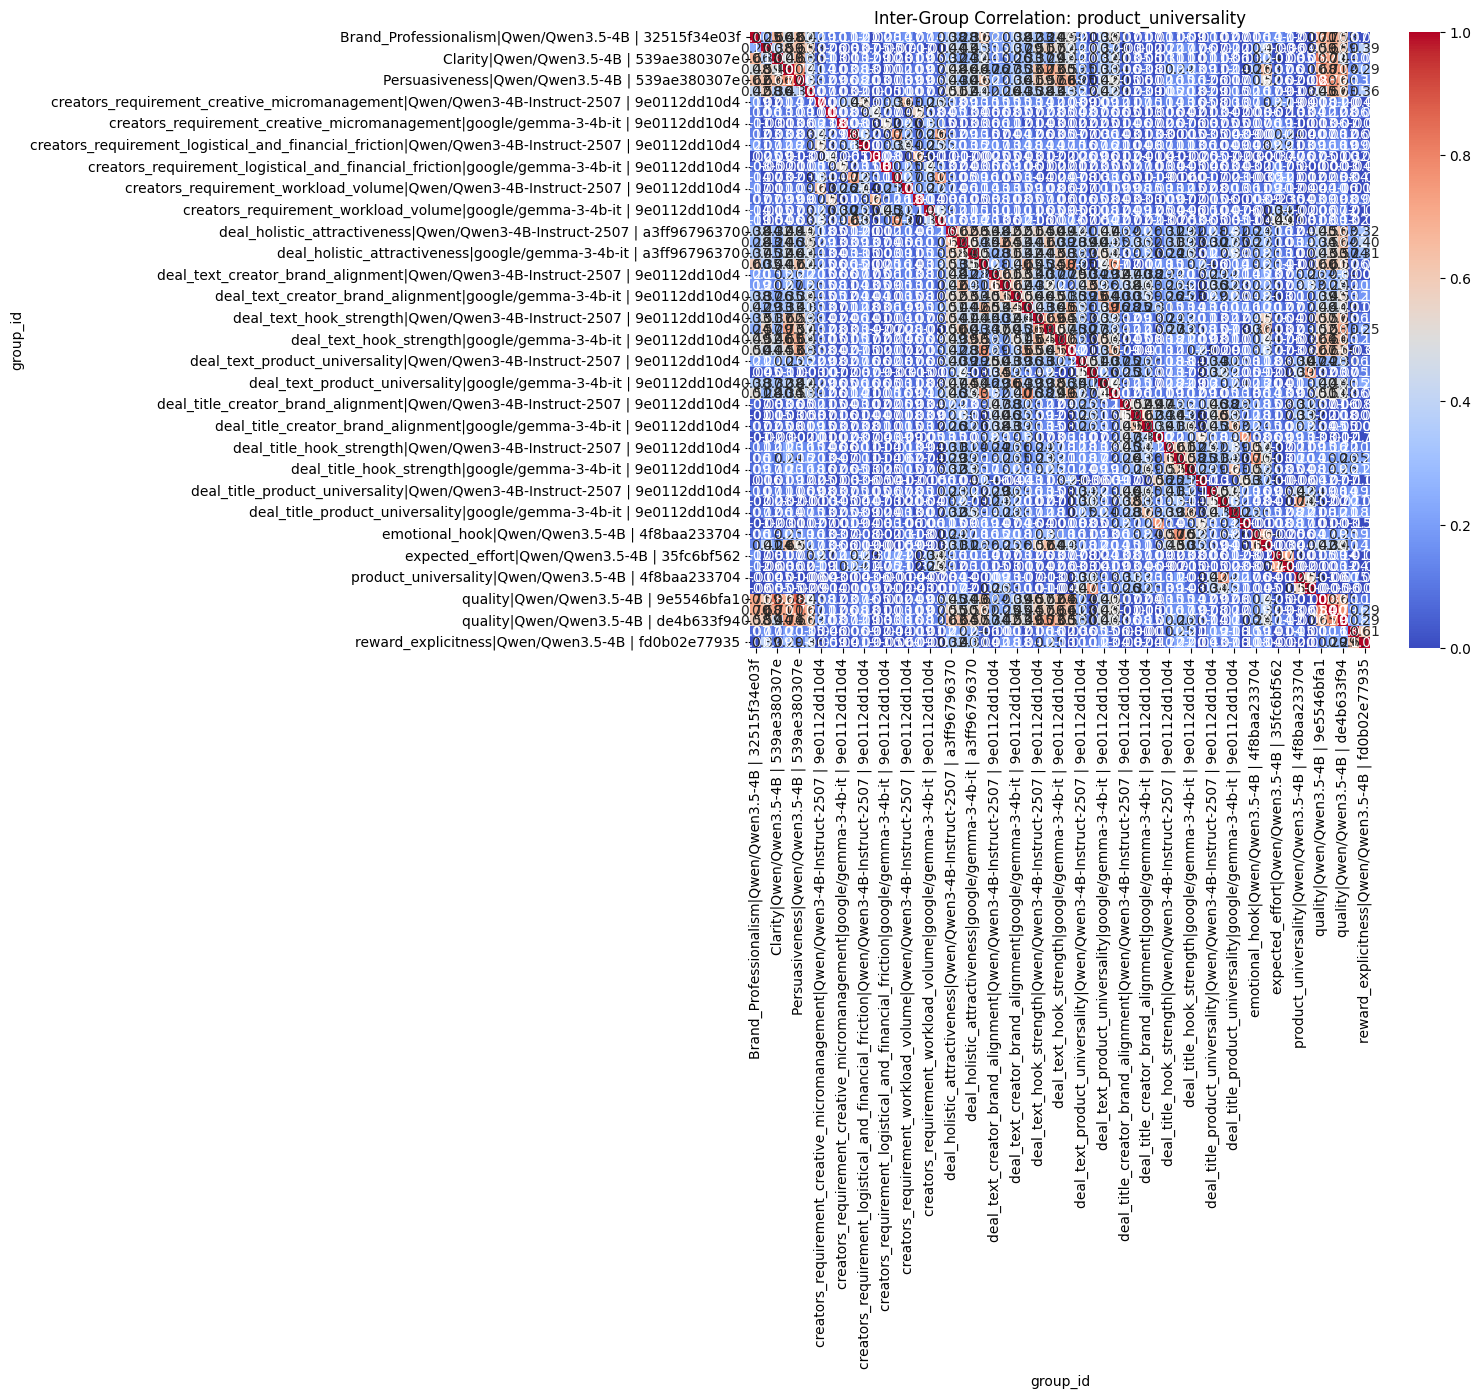

group_id,Brand_Professionalism|Qwen/Qwen3.5-4B | 32515f34e03f,Call-to-action strength|Qwen/Qwen3.5-4B | 539ae380307e,Clarity|Qwen/Qwen3.5-4B | 539ae380307e,Hook_Strength|Qwen/Qwen3.5-4B | 32515f34e03f,Persuasiveness|Qwen/Qwen3.5-4B | 539ae380307e,Task_Clarity|Qwen/Qwen3.5-4B | 32515f34e03f,creators_requirement_creative_micromanagement|Qwen/Qwen3-4B-Instruct-2507 | 9e0112dd10d4,creators_requirement_creative_micromanagement|Qwen/Qwen3.5-4B | 9e0112dd10d4,creators_requirement_creative_micromanagement|google/gemma-3-4b-it | 9e0112dd10d4,creators_requirement_creative_micromanagement|meta-llama/Llama-3.2-3B-Instruct | 9e0112dd10d4,...,emotional_hook|Qwen/Qwen3.5-4B | fd0b02e77935,expected_effort|Qwen/Qwen3.5-4B | 35fc6bf562,expected_effort|Qwen/Qwen3.5-4B | 5b26cd72bc,product_universality|Qwen/Qwen3.5-4B | 4f8baa233704,product_universality|Qwen/Qwen3.5-4B | fd0b02e77935,quality|Qwen/Qwen3.5-4B | 9e5546bfa1,quality|Qwen/Qwen3.5-4B | d6ac463714,quality|Qwen/Qwen3.5-4B | de4b633f94,reward_explicitness|Qwen/Qwen3.5-4B | 4f8baa233704,reward_explicitness|Qwen/Qwen3.5-4B | fd0b02e77935
group_id,,,,,,,,,,,,,,,,,,,,,
Brand_Professionalism|Qwen/Qwen3.5-4B | 32515f34e03f,1.000000,0.245959,0.659984,0.478944,0.624232,0.424247,0.185436,0.103733,0.107620,0.122631,...,0.138886,0.166463,0.117414,-0.006970,-0.058239,0.713309,0.701634,0.581254,0.065565,0.010446
Call-to-action strength|Qwen/Qwen3.5-4B | 539ae380307e,0.245959,1.000000,0.378933,0.585048,0.626133,0.575874,0.020007,0.056367,-0.026496,0.025960,...,0.414295,-0.030560,-0.063882,-0.041791,-0.048834,0.587115,0.675444,0.591130,0.168484,0.390772
Clarity|Qwen/Qwen3.5-4B | 539ae380307e,0.659984,0.378933,1.000000,0.484038,0.662556,0.363780,0.009828,0.132186,-0.009455,0.027301,...,0.242082,0.009285,-0.034041,0.046943,0.046476,0.824595,0.709100,0.438108,0.098424,0.092936
Hook_Strength|Qwen/Qwen3.5-4B | 32515f34e03f,0.478944,0.585048,0.484038,1.000000,0.770926,0.407028,0.140715,0.095489,0.029683,0.075136,...,0.627695,0.073822,0.062517,0.013382,0.048494,0.681137,0.707724,0.739056,0.195084,0.285201
Persuasiveness|Qwen/Qwen3.5-4B | 539ae380307e,0.624232,0.626133,0.662556,0.770926,1.000000,0.381234,0.124808,0.088241,0.056941,0.084597,...,0.520459,0.063722,0.024400,0.002241,-0.018894,0.883011,0.794195,0.656210,0.131043,0.143330
Task_Clarity|Qwen/Qwen3.5-4B | 32515f34e03f,0.424247,0.575874,0.363780,0.407028,0.381234,1.000000,0.065361,0.095791,0.032065,0.023987,...,0.170361,0.090417,0.012971,-0.060908,-0.091476,0.452866,0.670255,0.631799,0.149462,0.355316
creators_requirement_creative_micromanagement|Qwen/Qwen3-4B-Instruct-2507 | 9e0112dd10d4,0.185436,0.020007,0.009828,0.140715,0.124808,0.065361,1.000000,0.001516,0.229727,0.420755,...,0.128833,0.265386,0.189161,-0.044194,-0.006706,0.075151,0.107986,0.196022,-0.042413,-0.054706
creators_requirement_creative_micromanagement|Qwen/Qwen3.5-4B | 9e0112dd10d4,0.103733,0.056367,0.132186,0.095489,0.088241,0.095791,0.001516,1.000000,0.076412,0.087230,...,0.061471,0.018567,-0.129706,0.033896,0.039890,0.118093,0.123128,0.082911,0.059610,0.090415
creators_requirement_creative_micromanagement|google/gemma-3-4b-it | 9e0112dd10d4,0.107620,-0.026496,-0.009455,0.029683,0.056941,0.032065,0.229727,0.076412,1.000000,0.083662,...,0.062940,0.189990,0.111753,0.004824,-0.013931,0.029399,0.056247,0.070518,-0.000931,-0.036863


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def analyze_group_correlations(df, dimension="product_universality", score_col="mean_rating"):
    """
    Pivots long-form LLM data to compare experimental groups (Model + Prompt) 
    against each other for a specific dimension.
    """
    # 1. Create a unique identifier for each experimental group
    df = df.copy()
    df['group_id'] = df['dimension_name'] + "|" + \
        df['model_name'] + " | " + df['prompt_id']
    dim_df = df
    # 2. Filter for the dimension of interest
    # dim_df = df[df['dimension_name'] == dimension]

    # 3. Pivot to wide format
    # Index should be your unique deal identifier (e.g., 'deal_id' or 'id')
    # Use whatever column uniquely identifies the text being rated.
    pivot_df = dim_df.pivot_table(
        index='deal_id',
        columns='group_id',
        values=score_col
    )

    # 4. Calculate Correlation Matrix
    corr_matrix = pivot_df.corr()

    # 5. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
                fmt=".2f", vmin=0, vmax=1)
    plt.title(f"Inter-Group Correlation: {dimension}")
    plt.show()

    return corr_matrix


# Run the analysis
corr_results = analyze_group_correlations(final_df)
corr_results

In [18]:
final_df.groupby(experimental_groups)[
    ['mean_rating', 'log_apps_after_7_days']].corr()

mean_rating  \
model_name                       prompt_id    dimension_name                                                                          
Qwen/Qwen3-4B-Instruct-2507      9e0112dd10d4 creators_requirement_creative_micromanagement      mean_rating               1.000000   
                                                                                                 log_apps_after_7_days     0.031026   
                                              creators_requirement_logistical_and_financial_f... mean_rating               1.000000   
                                                                                                 log_apps_after_7_days     0.062733   
                                              creators_requirement_workload_volume               mean_rating               1.000000   
...                                                                                                                             ...   
meta-llama/Llama-3.2-3B-Instruct 9e0112dd10d4 deal_title_hook_strength                           log_apps_after_7_days     0.026490   
                                              deal_title_product_universality                    mean_rating               1.000000   
                                                                                                 log_apps_after_7_days     0.093800   
                                 a3ff96796370 deal_holistic_attractiveness                       mean_rating               1.000000   
                                                                                                 log_apps_after_7_days     0.019491   

                                                                                                                        log_apps_after_7_days  
model_name                       prompt_id    dimension_name                                                                                   
Qwen/Qwen3-4B-Instruct-2507      9e0112dd10d4 creators_requirement_creative_micromanagement      mean_rating                         0.031026  
                                                                                                 log_apps_after_7_days               1.000000  
                                              creators_requirement_logistical_and_financial_f... mean_rating                         0.062733  
                                                                                                 log_apps_after_7_days               1.000000  
                                              creators_requirement_workload_volume               mean_rating                         0.018609  
...                                                                                                                                       ...  
meta-llama/Llama-3.2-3B-Instruct 9e0112dd10d4 deal_title_hook_strength                           log_apps_after_7_days               1.000000  
                                              deal_title_product_universality                    mean_rating                         0.093800  
                                                                                                 log_apps_after_7_days               1.000000  
                                 a3ff96796370 deal_holistic_attractiveness                       mean_rating                         0.019491  
                                                                                                 log_apps_after_7_days               1.000000  

[114 rows x 2 columns]

# Analysis

## Regression

In [19]:
final_df.columns

Index(['applicants_applications_count', 'content_types', 'deal_id',
       'main_image', 'min_social_media_followers', 'deal_tags', 'live_since',
       'first_application_at', 'last_application_at', 'company_locations',
       'created_at', 'updated_at', 'deleted_at', 'legacy_partner_id',
       'deal_title', 'deal_text', 'creators_requirement', 'hash_tags',
       'status', 'deal_value', 'go_live_at', 'live_until', 'deal_type',
       'images', 'business_tone', 'ai_enhanced', 'accepts_international',
       'accepted_countries', 'social_requirement_type_id', 'product_name',
       'schedule_type', 'schedule_model', 'legacy_id', 'tags', 'gender',
       'featured_image', 'company_id', 'partner_id', 'diff_created_deleted',
       'diff_updated_deleted', 'text_word_count', 'title_word_count',
       'company_location_id', 'apps_after_7_days', 'online_active_0_7d',
       'online_active_7_30d', 'phys_active_0_7d_0_10km',
       'phys_active_0_7d_10_20km', 'phys_active_0_7d_20_50km',
    

In [20]:
# The variables you want to test
CATEGORICALS = ['market_scope', 'consolidated_categories']

CONTINUOUS = ['competitor_density']
active_creators_cols = ['log_online_active_0_7d']
# active_creators_cols = ['log_online_active_0_7d', 'log_online_active_7_30d']
# active_creators_cols = ['log_online_active_0_7d', 'log_online_active_7_30d', 'log_phys_active_0_7d_10_20km', 'log_phys_active_0_7d_20_50km', 'log_phys_active_7_30d_0_10km', 'log_phys_active_7_30d_10_20km', 'log_phys_active_7_30d_20_50km']
# CONTINUOUS = ['competitor_density', 'log_physical_active_creators_7d_50km', 'log_online_eligible_last_week']

CONTINUOUS += active_creators_cols

BINARIES = ['accepts_international']
# BINARIES = ['is_live']
# BINARIES = ['strict_follower_requirement']
BINARIES = []

# Experimental groups (required by your BaseRegressionRunner)
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']

### Combine all LLM measurements

In [21]:
# for id in prompts_to_include:
#     for key in pm.suites[id].templates.keys():
#         print(f"{id}:{key}")
        

In [22]:
# all_variables

In [23]:
# 1. Create a copy of your balanced dataframe
mega_df = final_df_balanced.copy()


prompts_to_include = ['fd0b02e77935', '4f8baa233704', '9e0112dd10d4', 'd52396d360bf', 'a3ff96796370']
# prompts_to_include = ['4f8baa233704', '9e0112dd10d4']
# prompts_to_include = ['fd0b02e77935', '4f8baa233704']

mega_df = mega_df[mega_df['prompt_id'].isin(prompts_to_include)]


# 2. Create a globally unique dimension name by concatenating the metadata
mega_df['dimension_name'] = (
    mega_df['model_name'] + "_" +
    mega_df['prompt_id'] + "_" +
    mega_df['dimension_name']
)



# 3. Create a single dummy group so the runner doesn't split the data
mega_df['mega_group'] = 'all_predictors'


In [24]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Get all unique dimensions from your mega dataframe
all_variables = sorted(mega_df['dimension_name'].unique().tolist())

# 2. Create the interactive multi-select widget
variable_selector = widgets.SelectMultiple(
    options=all_variables,
    value=all_variables,  # Default selects all of them (Kitchen Sink)
    rows=15,
    description='Variables:',
    layout=widgets.Layout(width='80%')
)

run_button = widgets.Button(
    description='Run Custom Model',
    button_style='success',
    icon='play'
)

output_area = widgets.Output()

def run_custom_regression(b):
    with output_area:
        clear_output(wait=True)
        selected_vars = list(variable_selector.value)
        
        if not selected_vars:
            print("⚠️ Please select at least one variable.")
            return
            
        print(f"🚀 Running OLS with {len(selected_vars)} selected dimensions...\n")
        
        # CORE MECHANIC: Filter the long dataframe to ONLY include selected variables
        # When the runner pivots this, the excluded variables simply won't exist!
        filtered_df = mega_df[mega_df['dimension_name'].isin(selected_vars)].copy()
        
        # Re-initialize the runner
        custom_runner = create_regression_runner(
            target_col='log_apps_after_7_days',
            experimental_groups=['mega_group'],
            cluster_col='partner_id',
            model_type='ols'
        )
        
        # Fit the model
        custom_runner.run_regression(
            df=filtered_df,
            cat_vars=CATEGORICALS,
            bin_vars=BINARIES,
            num_vars=CONTINUOUS,
            predictor_name='mean_rating'
        )
        
        # Display the statsmodels summary table
        # The key is ('mega_group',) because of how groupby handles single-item lists
        result = custom_runner.results["('all_predictors',)"]
        if result:
            print(result.summary())
        else:
            print("🚨 Model failed to converge. Check your variable mix.")

# 3. Render the UI
run_button.on_click(run_custom_regression)
display(variable_selector, run_button, output_area)

SelectMultiple(description='Variables:', index=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, …

Button(button_style='success', description='Run Custom Model', icon='play', style=ButtonStyle())

Output()

In [25]:

# 4. Initialize the runner with the dummy group
mega_runner = create_regression_runner(
    target_col='log_apps_after_7_days',
    experimental_groups=['mega_group'],  # <--- Use the dummy group!
    cluster_col='partner_id',
    model_type='ols'
)

# 5. Run the "Kitchen Sink" regression
mega_runner.run_regression(
    df=mega_df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    predictor_name='mean_rating'
)

mega_runner.results["('all_predictors',)"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     log_apps_after_7_days   R-squared:                       0.466
Model:                               OLS   Adj. R-squared:                  0.448
Method:                    Least Squares   F-statistic:                     22.53
Date:                   Tue, 31 Mar 2026   Prob (F-statistic):          4.90e-179
Time:                           01:21:16   Log-Likelihood:                -3304.7
No. Observations:                   2599   AIC:                             6781.
Df Residuals:                       2513   BIC:                             7286.
Df Model:                             85                                         
Covariance Type:                 cluster                                         
========================================================================================================================================================================
                                                                                                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
const                                                                                                   -4.0322      0.699     -5.770      0.000      -5.404      -2.661
google/gemma-3-4b-it_9e0112dd10d4_deal_title_product_universality                                        0.0987      0.053      1.855      0.064      -0.006       0.203
google/gemma-3-4b-it_9e0112dd10d4_deal_title_hook_strength                                              -0.1582      0.057     -2.784      0.005      -0.270      -0.047
google/gemma-3-4b-it_9e0112dd10d4_deal_title_creator_brand_alignment                                     0.0467      0.052      0.896      0.370      -0.056       0.149
google/gemma-3-4b-it_9e0112dd10d4_deal_text_product_universality                                         0.1112      0.052      2.141      0.033       0.009       0.213
google/gemma-3-4b-it_9e0112dd10d4_deal_text_hook_strength                                                0.0058      0.049      0.117      0.907      -0.091       0.103
google/gemma-3-4b-it_9e0112dd10d4_deal_text_creator_brand_alignment                                      0.0505      0.050      1.012      0.312      -0.047       0.149
google/gemma-3-4b-it_9e0112dd10d4_creators_requirement_workload_volume                                   0.1296      0.048      2.708      0.007       0.036       0.223
google/gemma-3-4b-it_9e0112dd10d4_creators_requirement_creative_micromanagement                          0.0796      0.082      0.969      0.333      -0.082       0.241
google/gemma-3-4b-it_9e0112dd10d4_creators_requirement_logistical_and_financial_friction                -0.0856      0.058     -1.470      0.142      -0.200       0.029
google/gemma-3-4b-it_a3ff96796370_deal_holistic_attractiveness                                           0.0597      0.059      1.012      0.312      -0.056       0.175
meta-llama/Llama-3.2-3B-Instruct_9e0112dd10d4_deal_title_product_universality                           -0.2190      0.095     -2.309      0.021      -0.405      -0.033
meta-llama/Llama-3.2-3B-Instruct_9e0112dd10d4_deal_title_hook_strength                                   0.1255      0.073      1.713      0.087      -0.018       0.269
meta-llama/Llama-3.2-3B-Instruct_9e0112dd10d4_deal_title_creator_brand_alignment                         0.2293      0.085      2.700      0.007       0.063       0.396
meta-llama/Llama-3.2-3B-Instruct_9e0112dd10d4_deal_text_product_universality                            -0.1376      0.075     -1.827      0.068      -0.285       0.010
meta-lla

In [26]:
mega_runner.results

{"('all_predictors',)": <statsmodels.regression.linear_model.OLSResults at 0x23d4eb92210>}

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd


def check_universality_vif(mega_model):
    """Calculates VIF for the design matrix to check for multicollinearity."""
    vif_data = pd.DataFrame()
    vif_data["Feature"] = mega_model.exog_names

    # Calculate VIF for each feature
    vif_data["VIF"] = [
        variance_inflation_factor(mega_model.exog, i)
        for i in range(len(mega_model.exog_names))
    ]

    # Filter to just look at our variables of interest
    target_vifs = vif_data[vif_data['Feature'].str.contains('Qwen')]
    print("Variance Inflation Factors:")
    display(target_vifs)


mega_model = mega_runner.results["('all_predictors',)"].model
# Assuming X_clean is your final predictor matrix before calling sm.OLS()
check_universality_vif(mega_model)

Variance Inflation Factors:


,Feature,VIF
21,Qwen/Qwen3-4B-Instruct-2507_9e0112dd10d4_deal_...,2.199654
22,Qwen/Qwen3-4B-Instruct-2507_9e0112dd10d4_deal_...,2.330067
23,Qwen/Qwen3-4B-Instruct-2507_9e0112dd10d4_deal_...,2.399975
24,Qwen/Qwen3-4B-Instruct-2507_9e0112dd10d4_deal_...,2.052463
25,Qwen/Qwen3-4B-Instruct-2507_9e0112dd10d4_deal_...,3.001951
26,Qwen/Qwen3-4B-Instruct-2507_9e0112dd10d4_deal_...,2.571302
27,Qwen/Qwen3-4B-Instruct-2507_9e0112dd10d4_creat...,1.947624
28,Qwen/Qwen3-4B-Instruct-2507_9e0112dd10d4_creat...,2.321664
29,Qwen/Qwen3-4B-Instruct-2507_9e0112dd10d4_creat...,1.716069
30,Qwen/Qwen3-4B-Instruct-2507_a3ff96796370_deal_...,2.810041


### Split by Experimental Group (model_name, prompt_id)

In [28]:
final_df_balanced.loc[:,
                      'mean_rating_binary'] = final_df_balanced['mean_rating'] > 3.5

### With control variables

In [29]:
prompt_map

{'35fc6bf562': 'concise_bars_effort_single_sentence',
 '5b26cd72bc': 'naive_holistic_effort',
 '9e0112dd10d4': 'Comprehensive formative suite across Title, Text, and Requirements',
 '4f8baa233704': 'formative suite for deal titles',
 'fd0b02e77935': 'formative suite for deal titles',
 '539ae380307e': 'naive formative',
 'd52396d360bf': 'rubric-grounded formative suite',
 '32515f34e03f': 'Concise XML formative suite for small models',
 'a3ff96796370': 'Holistic baseline measuring overall deal attractiveness for incremental validity testing.',
 'd6ac463714': 'BARS_holistic',
 'de4b633f94': 'BARS_XML_holistic',
 '9e5546bfa1': 'naive_holistic'}

In [30]:
runner = create_regression_runner(
    target_col='log_apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='ols'
)

runner.run_baseline_model(
    df=og_df_balanced,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="baseline_model_OLS"
)

runner.run_regression(df=final_df_balanced,
                      cat_vars=CATEGORICALS,
                      bin_vars=BINARIES,
                      num_vars=CONTINUOUS,
                      predictor_name='mean_rating')

interactive_regression_results_selector(runner.results)

Dropdown(description='Select option:', index=16, layout=Layout(width='400px'), options=('baseline_model_OLS', …

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     log_apps_after_7_days   R-squared:                       0.382
Model:                               OLS   Adj. R-squared:                  0.371
Method:                    Least Squares   F-statistic:                     22.58
Date:                   Tue, 31 Mar 2026   Prob (F-statistic):          3.13e-127
Time:                           01:24:16   Log-Likelihood:                -3495.0
No. Observations:                   2599   AIC:                             7088.
Df Residuals:                       2550   BIC:                             7375.
Df Model:                             48                                         
Covariance Type:                 cluster                                         
==========================================================================================================================
                                                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
const                                                     -1.0621      0.665     -1.598      0.110      -2.366       0.242
deal_title_product_universality                           -0.1665      0.092     -1.813      0.070      -0.347       0.014
deal_title_hook_strength                                  -0.0801      0.072     -1.105      0.270      -0.222       0.062
deal_title_creator_brand_alignment                         0.4223      0.086      4.938      0.000       0.254       0.590
deal_text_product_universality                             0.0069      0.079      0.087      0.930      -0.148       0.162
deal_text_hook_strength                                   -0.1648      0.050     -3.291      0.001      -0.263      -0.067
deal_text_creator_brand_alignment                          0.1966      0.061      3.210      0.001       0.076       0.317
creators_requirement_workload_volume                      -0.2257      0.134     -1.681      0.093      -0.489       0.038
creators_requirement_creative_micromanagement             -0.0422      0.099     -0.427      0.670      -0.236       0.152
creators_requirement_logistical_and_financial_friction     0.1216      0.101      1.205      0.229      -0.076       0.320
competitor_density                                        -0.0422      0.011     -3.781      0.000      -0.064      -0.020
log_online_active_0_7d                                     0.5749      0.097      5.952      0.000       0.385       0.764
market_scope_Tier2_NLD_only                               -0.2572      0.075     -3.451      0.001      -0.403      -0.111
market_scope_Tier3_BEL_Only                               -1.1984      0.169     -7.098      0.000      -1.530      -0.867
market_scope_Tier4_Germany                                -1.3073      0.066    -19.837      0.000      -1.437      -1.178
consolidated_categories_Activities_Sport                   0.1176      0.214      0.549      0.583      -0.303       0.538
consolidated_categories_Animals_Lifestyle                 -0.1655      0.225     -0.737      0.461      -0.606       0.275
consolidated_categories_Beauty_Fashion                     0.6499      0.241      2.698      0.007       0.177       1.123
consolidated_categories_Beauty_UGC                         0.4759      0.203      2.341      0.019       0.077       0.875
consolidated_categories_Cars_Lifestyle                     0.1240      0.275      0.451      0.652      -0.416       0.664
consolidated_categories_Cooking_Food                       0.3341      0.240      1.390      0.165      -0.138       0.806
consolidated_categories_Cooking_Vegan                     -0.1265      0.342     -0.370      0.712

In [31]:
# for i in range(30):
#     row = og_df_balanced.iloc[i]
#     print(
#         f"<title>{row['creators_requirement']}</title> <applications>{row['apps_after_7_days']}</applications>")

## Model diagnostics

In [32]:
import pandas as pd
import numpy as np
import ast
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.sm_exceptions import InvalidTestWarning
from IPython.display import display


def generate_master_diagnostic_table(results_dict, baseline_key='baseline_model_OLS'):
    """
    Generates a master diagnostic table including MSE, AIC/BIC, and Joint F-tests.
    Ensures all comparisons are made against a fixed baseline.
    """
    if baseline_key not in results_dict:
        raise ValueError(
            f"Baseline key '{baseline_key}' not found in results dictionary.")

    baseline_fit = results_dict[baseline_key]
    baseline_vars = set(baseline_fit.model.exog_names)

    # Baseline Metrics
    base_n = baseline_fit.nobs
    base_mse = baseline_fit.ssr / base_n  # Sum of Squared Residuals / N
    base_aic = baseline_fit.aic
    base_bic = baseline_fit.bic
    base_adj_r2 = baseline_fit.rsquared_adj

    diagnostic_rows = []

    for key, fit_obj in results_dict.items():
        if key == baseline_key:
            continue

        # 1. Parse Key
        try:
            parsed_key = ast.literal_eval(key)
            model_name = parsed_key[0]
            prompt_hash = parsed_key[1]
        except (ValueError, SyntaxError):
            model_name = key
            prompt_hash = "N/A"

        # 2. Dynamic Variable Detection
        exog_names = list(fit_obj.model.exog_names)
        llm_vars = [var for var in exog_names if var not in baseline_vars]

        # 3. LLM Statistics (VIF/Coef/P-val)
        vifs = []
        for var in llm_vars:
            idx = exog_names.index(var)
            try:
                vif = variance_inflation_factor(fit_obj.model.exog, idx)
                vifs.append(f"{var}: {vif:.1f}")
            except:
                vifs.append(f"{var}: NaN")

        # 4. Error Metrics
        current_mse = fit_obj.ssr / fit_obj.nobs
        delta_mse = current_mse - base_mse
        delta_adj_r2 = fit_obj.rsquared_adj - base_adj_r2
        prct_adj_r2 = delta_adj_r2 / base_adj_r2
        delta_aic = fit_obj.aic - base_aic
        delta_bic = fit_obj.bic - base_bic

        # 5. Joint F-Test
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", InvalidTestWarning)
            try:
                f_test_res = fit_obj.compare_f_test(baseline_fit)
                f_stat, f_p_val = f_test_res[0], f_test_res[1]
            except:
                f_stat, f_p_val = np.nan, np.nan

        diagnostic_rows.append({
            'LLM Model': model_name,
            'Prompt Hash': prompt_hash,
            'MSE': current_mse,
            'Δ MSE': delta_mse,
            'Δ Adj R²': delta_adj_r2,
            '+% Adj R²': prct_adj_r2,
            'Δ AIC': delta_aic,
            'Δ BIC': delta_bic,
            'Joint F P-val': f_p_val,
            'VIFs': " | ".join(vifs)
        })

    df_diag = pd.DataFrame(diagnostic_rows)
    return df_diag.sort_values('Δ MSE', ascending=True).reset_index(drop=True)


# --- Execute and Display ---
df_master = generate_master_diagnostic_table(runner.results)

# Style helper


def style_mse(val):
    if val < 0:
        return 'color: green'  # Lower error is better
    if val > 0:
        return 'color: red'
    return ''


styled_df = df_master.style\
    .applymap(style_mse, subset=['Δ MSE'])\
    .format({
        'MSE': '{:.6f}',
        'Δ MSE': '{:.6f}',
        'Δ Adj R²': '{:.5f}',
        'Δ AIC': '{:.2f}',
        'Δ BIC': '{:.2f}',
        'Joint F P-val': '{:.4f}'
    })

display(styled_df)

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_47532\3172690551.py:107: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(style_mse, subset=['Δ MSE'])\


,LLM Model,Prompt Hash,MSE,Δ MSE,Δ Adj R²,+% Adj R²,Δ AIC,Δ BIC,Joint F P-val,VIFs
0,Qwen/Qwen3.5-4B,9e0112dd10d4,0.794212,-0.102229,0.07233,0.207895,-296.69,-243.93,0.0000,deal_title_product_universality: 1.7 | deal_title_hook_strength: 1.5 | deal_title_creator_brand_alignment: 2.1 | deal_text_product_universality: 1.8 | deal_text_hook_strength: 1.6 | deal_text_creator_brand_alignment: 2.5 | creators_requirement_workload_volume: 2.2 | creators_requirement_creative_micromanagement: 1.6 | creators_requirement_logistical_and_financial_friction: 2.0
1,Qwen/Qwen3-4B-Instruct-2507,9e0112dd10d4,0.816880,-0.079561,0.05578,0.160330,-223.55,-170.79,0.0000,deal_title_product_universality: 1.5 | deal_title_hook_strength: 1.5 | deal_title_creator_brand_alignment: 1.9 | deal_text_product_universality: 1.5 | deal_text_hook_strength: 1.4 | deal_text_creator_brand_alignment: 2.0 | creators_requirement_workload_volume: 1.8 | creators_requirement_creative_micromanagement: 2.0 | creators_requirement_logistical_and_financial_friction: 1.5
2,Qwen/Qwen3.5-4B,fd0b02e77935,0.817899,-0.078542,0.05644,0.162220,-232.31,-214.72,0.0000,reward_explicitness: 1.1 | product_universality: 1.1 | emotional_hook: 1.1
3,google/gemma-3-4b-it,9e0112dd10d4,0.841668,-0.054773,0.03768,0.108316,-145.86,-93.09,0.0000,deal_title_product_universality: 2.3 | deal_title_hook_strength: 1.8 | deal_title_creator_brand_alignment: 2.2 | deal_text_product_universality: 2.1 | deal_text_hook_strength: 1.7 | deal_text_creator_brand_alignment: 2.4 | creators_requirement_workload_volume: 1.3 | creators_requirement_creative_micromanagement: 1.5 | creators_requirement_logistical_and_financial_friction: 1.6
4,Qwen/Qwen3.5-4B,4f8baa233704,0.846148,-0.050293,0.03586,0.103084,-144.06,-126.47,0.0000,reward_explicitness: 1.1 | product_universality: 1.1 | emotional_hook: 1.1
5,meta-llama/Llama-3.2-3B-Instruct,9e0112dd10d4,0.862134,-0.034307,0.02274,0.065372,-83.42,-30.65,0.0000,deal_title_product_universality: 2.8 | deal_title_hook_strength: 1.9 | deal_title_creator_brand_alignment: 3.4 | deal_text_product_universality: 3.2 | deal_text_hook_strength: 2.4 | deal_text_creator_brand_alignment: 3.5 | creators_requirement_workload_volume: 2.7 | creators_requirement_creative_micromanagement: 2.4 | creators_requirement_logistical_and_financial_friction: 2.9
6,Qwen/Qwen3.5-4B,a3ff96796370,0.878665,-0.017776,0.01268,0.036450,-50.05,-44.19,0.0000,deal_holistic_attractiveness: 1.1
7,Qwen/Qwen3-4B-Instruct-2507,a3ff96796370,0.890581,-0.005860,0.00401,0.011524,-15.04,-9.18,0.0000,deal_holistic_attractiveness: 1.1
8,google/gemma-3-4b-it,a3ff96796370,0.892068,-0.004373,0.00293,0.008414,-10.71,-4.85,0.0004,deal_holistic_attractiveness: 1.1
9,Qwen/Qwen3.5-4B,5b26cd72bc,0.893631,-0.002811,0.00179,0.005146,-6.16,-0.30,0.0046,expected_effort: 1.0


In [33]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


def compare_models_oos(
    df,
    outcome_col,
    baseline_cols,
    llm_cols,
    group_col="input_id",
    n_splits=5
):
    cols = [outcome_col, group_col] + baseline_cols + llm_cols
    # Important: Drop NA here ensures we only evaluate on inputs that have ratings
    # for ALL dimensions. If an LLM missed one dimension, that input is dropped.
    data = df[cols].dropna().copy()

    X_base = data[baseline_cols].values
    X_full = data[baseline_cols + llm_cols].values
    y = data[outcome_col].values
    groups = data[group_col].values

    gkf = GroupKFold(n_splits=n_splits)

    rows = []
    y_true_all = []
    y_pred_base_all = []
    y_pred_full_all = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_base, y, groups=groups), start=1):
        Xb_train, Xb_test = X_base[train_idx], X_base[test_idx]
        Xf_train, Xf_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        base_model = LinearRegression()
        full_model = LinearRegression()

        base_model.fit(Xb_train, y_train)
        full_model.fit(Xf_train, y_train)

        y_pred_base = base_model.predict(Xb_test)
        y_pred_full = full_model.predict(Xf_test)

        mse_base = mean_squared_error(y_test, y_pred_base)
        mse_full = mean_squared_error(y_test, y_pred_full)

        r2_base = r2_score(y_test, y_pred_base)
        r2_full = r2_score(y_test, y_pred_full)

        rows.append({
            "fold": fold,
            "n_test": len(test_idx),
            "mse_base": mse_base,
            "mse_full": mse_full,
            "delta_mse": mse_full - mse_base,
            "rmse_base": np.sqrt(mse_base),
            "rmse_full": np.sqrt(mse_full),
            "delta_rmse": np.sqrt(mse_full) - np.sqrt(mse_base),
            "r2_base": r2_base,
            "r2_full": r2_full,
            "delta_r2": r2_full - r2_base,
            "improved_mse": mse_full < mse_base,
            "improved_r2": r2_full > r2_base,
        })

        y_true_all.extend(y_test)
        y_pred_base_all.extend(y_pred_base)
        y_pred_full_all.extend(y_pred_full)

    results = pd.DataFrame(rows)

    pooled_mse_base = mean_squared_error(y_true_all, y_pred_base_all)
    pooled_mse_full = mean_squared_error(y_true_all, y_pred_full_all)
    pooled_r2_base = r2_score(y_true_all, y_pred_base_all)
    pooled_r2_full = r2_score(y_true_all, y_pred_full_all)

    overall = {
        "n_obs_used": len(data),
        "n_unique_groups": data[group_col].nunique(),
        "pooled_mse_base": pooled_mse_base,
        "pooled_mse_full": pooled_mse_full,
        "pooled_delta_mse": pooled_mse_full - pooled_mse_base,
        "pooled_rmse_base": np.sqrt(pooled_mse_base),
        "pooled_rmse_full": np.sqrt(pooled_mse_full),
        "pooled_delta_rmse": np.sqrt(pooled_mse_full) - np.sqrt(pooled_mse_base),
        "pooled_r2_base": pooled_r2_base,
        "pooled_r2_full": pooled_r2_full,
        "pooled_delta_r2": pooled_r2_full - pooled_r2_base,
        "folds_improved_mse": int(results["improved_mse"].sum()),
        "folds_improved_r2": int(results["improved_r2"].sum()),
        "n_folds": len(results),
    }

    return results, overall


def get_wide_subset(
    df,
    model_name,
    prompt_id,
    outcome_col,
    baseline_cols,
    dimension_col="dimension",
    rating_col="mean_rating",
    group_col="input_id"
):
    """
    Filters for a specific experimental condition and pivots dimensions into columns.
    """
    # 1. Isolate the specific experimental run
    subset = df.loc[
        (df["model_name"] == model_name) &
        (df["prompt_id"] == prompt_id)
    ].copy()

    # 2. Define the index columns that should NOT be pivoted
    # (everything constant for a specific input_id)
    index_cols = [group_col, outcome_col] + baseline_cols

    # 3. Pivot: Long to Wide
    # Using pivot_table with 'mean' aggfunc just in case there are accidental duplicates
    wide_df = subset.pivot_table(
        index=index_cols,
        columns=dimension_col,
        values=rating_col,
        aggfunc='mean'
    ).reset_index()

    # Clean up the columns name formatting from pandas pivot
    wide_df.columns.name = None

    # 4. Extract the dynamically created dimension column names
    # Any unique value that was in the dimension column is now a feature column
    llm_cols = list(subset[dimension_col].dropna().unique())

    return wide_df, llm_cols


def run_formative_oos(
    df,
    model_name,
    prompt_id,
    outcome_col,
    baseline_cols,
    dimension_col="dimension",
    rating_col="mean_rating",
    group_col="input_id",
    n_splits=5
):
    # Get the pivoted dataframe and the list of new dimension columns
    wide_subset, llm_cols = get_wide_subset(
        df=df,
        model_name=model_name,
        prompt_id=prompt_id,
        outcome_col=outcome_col,
        baseline_cols=baseline_cols,
        dimension_col=dimension_col,
        rating_col=rating_col,
        group_col=group_col
    )

    # Pass the wide data and dynamic llm_cols into the CV runner
    fold_results, overall = compare_models_oos(
        df=wide_subset,
        outcome_col=outcome_col,
        baseline_cols=baseline_cols,
        llm_cols=llm_cols,
        group_col=group_col,
        n_splits=n_splits
    )

    overall["model_name"] = model_name
    overall["prompt_id"] = prompt_id
    overall["dimensions_evaluated"] = ", ".join(llm_cols)
    overall["setup"] = "formative_wide"

    return fold_results, overall


def get_holistic_subset(df, model_name, prompt_id):
    """
    Filters the dataframe for a single holistic experimental run.
    """
    subset = df.loc[
        (df["model_name"] == model_name) &
        (df["prompt_id"] == prompt_id)
    ].copy()

    return subset


def run_holistic_oos(
    df,
    model_name,
    prompt_id,
    outcome_col,
    baseline_cols,
    rating_col="mean_rating",
    group_col="input_id",
    n_splits=5
):
    # 1. Isolate the specific experimental run
    subset = get_holistic_subset(df, model_name, prompt_id)

    # 2. Pass to the cross-validation runner
    # Note: llm_cols expects a list, so we wrap the rating_col in brackets
    fold_results, overall = compare_models_oos(
        df=subset,
        outcome_col=outcome_col,
        baseline_cols=baseline_cols,
        llm_cols=[rating_col],
        group_col=group_col,
        n_splits=n_splits
    )

    # 3. Add metadata for the master summary table
    overall["model_name"] = model_name
    overall["prompt_id"] = prompt_id
    overall["dimensions_evaluated"] = rating_col
    overall["setup"] = "holistic"

    return fold_results, overall


def get_holistic_subset(df, model_name, prompt_id):
    """
    Filters the dataframe for a single holistic experimental run.
    """
    subset = df.loc[
        (df["model_name"] == model_name) &
        (df["prompt_id"] == prompt_id)
    ].copy()

    return subset


def run_holistic_oos(
    df,
    model_name,
    prompt_id,
    outcome_col,
    baseline_cols,
    rating_col="mean_rating",
    group_col="input_id",
    n_splits=5
):
    # 1. Isolate the specific experimental run
    subset = get_holistic_subset(df, model_name, prompt_id)

    # 2. Pass to the cross-validation runner
    # Note: llm_cols expects a list, so we wrap the rating_col in brackets
    fold_results, overall = compare_models_oos(
        df=subset,
        outcome_col=outcome_col,
        baseline_cols=baseline_cols,
        llm_cols=[rating_col],
        group_col=group_col,
        n_splits=n_splits
    )

    # 3. Add metadata for the master summary table
    overall["model_name"] = model_name
    overall["prompt_id"] = prompt_id
    overall["dimensions_evaluated"] = rating_col
    overall["setup"] = "holistic"

    return fold_results, overall

In [34]:
import pandas as pd
import numpy as np

# 1. Define your exact variables
CATEGORICALS = ['market_scope', 'consolidated_categories']
CONTINUOUS = ['competitor_density']
active_creators_cols = ['log_online_active_0_7d', 'log_online_active_7_30d']
CONTINUOUS += active_creators_cols

BINARIES = ['strict_follower_requirement']  # Using your last active assignment
OUTCOME_COL = 'log_apps_after_7_days'


def run_all_cv_experiments(df, outcome_col, categoricals, continuous, binaries, group_col='input_id'):
    """
    Master runner for Out-Of-Sample Cross Validation.
    Handles dummy encoding and dynamically routes to holistic vs formative runs.
    """
    print("Pre-processing: One-Hot Encoding categorical variables for sklearn...")

    # Create a copy so we don't mutate the original dataframe
    model_df = df.copy()

    # 1. Dummy Encode Categoricals (drop_first=True avoids perfect multicollinearity)
    if categoricals:
        model_df = pd.get_dummies(
            model_df, columns=categoricals, drop_first=True, dtype=int)

    # 2. Reconstruct the dynamic list of baseline columns after dummy expansion
    baseline_cols = continuous + binaries
    if categoricals:
        for cat in categoricals:
            # Find all the newly created dummy columns for this category
            dummy_cols = [
                c for c in model_df.columns if c.startswith(f"{cat}_")]
            baseline_cols.extend(dummy_cols)

    print(f"Baseline features expanded to {len(baseline_cols)} columns.")

    # 3. Get unique experimental groups
    experiments = df[['model_name', 'prompt_id']].drop_duplicates()

    all_overalls = []
    all_fold_details = {}

    for _, row in experiments.iterrows():
        m_name = row['model_name']
        p_id = row['prompt_id']

        # Determine if formative or holistic based on unique dimensions
        subset = model_df[(model_df['model_name'] == m_name)
                          & (model_df['prompt_id'] == p_id)]
        unique_dims = subset['dimension_name'].dropna().unique()

        print(f"\nRunning CV for {m_name} | {p_id}...")

        if len(unique_dims) > 1:
            print(
                f"  -> Detected FORMATIVE prompt ({len(unique_dims)} dimensions). Pivoting to wide...")
            fold_res, overall = run_formative_oos(
                df=model_df,
                model_name=m_name,
                prompt_id=p_id,
                outcome_col=outcome_col,
                baseline_cols=baseline_cols,
                dimension_col='dimension_name',
                rating_col='mean_rating',
                group_col=group_col,
                n_splits=5
            )
        else:
            print(f"  -> Detected HOLISTIC prompt. Running standard regression...")
            fold_res, overall = run_holistic_oos(
                df=model_df,
                model_name=m_name,
                prompt_id=p_id,
                outcome_col=outcome_col,
                baseline_cols=baseline_cols,
                rating_col='mean_rating',
                group_col=group_col,
                n_splits=5
            )

        all_overalls.append(overall)
        all_fold_details[f"{m_name}_{p_id}"] = fold_res

    # Compile the final summary table
    df_summary = pd.DataFrame(all_overalls)

    # Sort by the pooled Delta MSE (Most negative / biggest drop is best)
    df_summary = df_summary.sort_values(
        'pooled_delta_mse', ascending=True).reset_index(drop=True)

    # Reorder columns for readability
    front_cols = ['model_name', 'prompt_id', 'setup',
                  'pooled_delta_mse', 'pooled_delta_r2', 'folds_improved_mse']
    back_cols = [c for c in df_summary.columns if c not in front_cols]
    df_summary = df_summary[front_cols + back_cols]

    return df_summary, all_fold_details


# ==========================================
# EXECUTION
# ==========================================
# Assuming your balanced dataframe is called `final_df`
summary_table, fold_level_results = run_all_cv_experiments(
    df=final_df,
    outcome_col=OUTCOME_COL,
    categoricals=CATEGORICALS,
    continuous=CONTINUOUS,
    binaries=BINARIES
)

print("\n" + "="*100)
print("🚀 OUT-OF-SAMPLE CROSS-VALIDATION RESULTS")
print("="*100)

# Beautiful Pandas Styler for the results


def style_oos_metrics(val, metric):
    if pd.isna(val):
        return ''
    if 'delta_mse' in metric or 'delta_rmse' in metric:
        return 'color: green' if val < 0 else 'color: red'
    if 'delta_r2' in metric:
        return 'color: green' if val > 0 else 'color: red'
    return ''


styled_summary = summary_table.style\
    .applymap(lambda x: style_oos_metrics(x, 'delta_mse'), subset=['pooled_delta_mse'])\
    .applymap(lambda x: style_oos_metrics(x, 'delta_r2'), subset=['pooled_delta_r2'])\
    .format({
        'pooled_delta_mse': '{:.5f}',
        'pooled_mse_base': '{:.5f}',
        'pooled_mse_full': '{:.5f}',
        'pooled_delta_r2': '{:.4f}',
        'pooled_r2_base': '{:.4f}',
        'pooled_r2_full': '{:.4f}',
    })

display(styled_summary)

Pre-processing: One-Hot Encoding categorical variables for sklearn...
Baseline features expanded to 41 columns.

Running CV for google/gemma-3-4b-it | 9e0112dd10d4...
  -> Detected FORMATIVE prompt (9 dimensions). Pivoting to wide...

Running CV for google/gemma-3-4b-it | a3ff96796370...
  -> Detected HOLISTIC prompt. Running standard regression...

Running CV for meta-llama/Llama-3.2-3B-Instruct | 9e0112dd10d4...
  -> Detected FORMATIVE prompt (9 dimensions). Pivoting to wide...

Running CV for meta-llama/Llama-3.2-3B-Instruct | a3ff96796370...
  -> Detected HOLISTIC prompt. Running standard regression...

Running CV for Qwen/Qwen3-4B-Instruct-2507 | 9e0112dd10d4...
  -> Detected FORMATIVE prompt (9 dimensions). Pivoting to wide...

Running CV for Qwen/Qwen3-4B-Instruct-2507 | a3ff96796370...
  -> Detected HOLISTIC prompt. Running standard regression...

Running CV for Qwen/Qwen3.5-4B | 32515f34e03f...
  -> Detected FORMATIVE prompt (3 dimensions). Pivoting to wide...

Running CV for 

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_47532\2803761215.py:133: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: style_oos_metrics(x, 'delta_mse'), subset=['pooled_delta_mse'])\
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_47532\2803761215.py:134: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: style_oos_metrics(x, 'delta_r2'), subset=['pooled_delta_r2'])\


,model_name,prompt_id,setup,pooled_delta_mse,pooled_delta_r2,folds_improved_mse,n_obs_used,n_unique_groups,pooled_mse_base,pooled_mse_full,pooled_rmse_base,pooled_rmse_full,pooled_delta_rmse,pooled_r2_base,pooled_r2_full,folds_improved_r2,n_folds,dimensions_evaluated
0,Qwen/Qwen3.5-4B,9e0112dd10d4,formative_wide,-0.10119,0.0725,5,2599,2599,0.92150,0.82032,0.959950,0.905714,-0.054235,0.3397,0.4122,5,5,"deal_title_product_universality, deal_title_hook_strength, deal_title_creator_brand_alignment, deal_text_product_universality, deal_text_hook_strength, deal_text_creator_brand_alignment, creators_requirement_workload_volume, creators_requirement_creative_micromanagement, creators_requirement_logistical_and_financial_friction"
1,Qwen/Qwen3.5-4B,fd0b02e77935,formative_wide,-0.07812,0.0560,5,2599,2599,0.92150,0.84339,0.959950,0.918360,-0.041589,0.3397,0.3957,5,5,"reward_explicitness, product_universality, emotional_hook"
2,Qwen/Qwen3-4B-Instruct-2507,9e0112dd10d4,formative_wide,-0.07588,0.0544,5,2599,2599,0.92150,0.84563,0.959950,0.919580,-0.040370,0.3397,0.3941,5,5,"deal_title_product_universality, deal_title_hook_strength, deal_title_creator_brand_alignment, deal_text_product_universality, deal_text_hook_strength, deal_text_creator_brand_alignment, creators_requirement_workload_volume, creators_requirement_creative_micromanagement, creators_requirement_logistical_and_financial_friction"
3,Qwen/Qwen3.5-4B,4f8baa233704,formative_wide,-0.05054,0.0362,5,2599,2599,0.92150,0.87096,0.959950,0.933254,-0.026696,0.3397,0.3759,5,5,"reward_explicitness, product_universality, emotional_hook"
4,google/gemma-3-4b-it,9e0112dd10d4,formative_wide,-0.04896,0.0351,5,2599,2599,0.92150,0.87254,0.959950,0.934099,-0.025851,0.3397,0.3748,5,5,"deal_title_product_universality, deal_title_hook_strength, deal_title_creator_brand_alignment, deal_text_product_universality, deal_text_hook_strength, deal_text_creator_brand_alignment, creators_requirement_workload_volume, creators_requirement_creative_micromanagement, creators_requirement_logistical_and_financial_friction"
5,meta-llama/Llama-3.2-3B-Instruct,9e0112dd10d4,formative_wide,-0.02822,0.0202,5,2599,2599,0.92150,0.89328,0.959950,0.945136,-0.014813,0.3397,0.3599,5,5,"deal_title_product_universality, deal_title_hook_strength, deal_title_creator_brand_alignment, deal_text_product_universality, deal_text_hook_strength, deal_text_creator_brand_alignment, creators_requirement_workload_volume, creators_requirement_creative_micromanagement, creators_requirement_logistical_and_financial_friction"
6,Qwen/Qwen3.5-4B,a3ff96796370,holistic,-0.01646,0.0118,4,2599,2599,0.92150,0.90504,0.959950,0.951336,-0.008613,0.3397,0.3515,4,5,mean_rating
7,Qwen/Qwen3-4B-Instruct-2507,a3ff96796370,holistic,-0.00572,0.0041,4,2599,2599,0.92150,0.91579,0.959950,0.956967,-0.002983,0.3397,0.3438,4,5,mean_rating
8,google/gemma-3-4b-it,a3ff96796370,holistic,-0.00335,0.0024,4,2599,2599,0.92150,0.91816,0.959950,0.958206,-0.001744,0.3397,0.3421,4,5,mean_rating
9,Qwen/Qwen3.5-4B,5b26cd72bc,holistic,-0.00209,0.0015,4,2599,2599,0.92150,0.91941,0.959950,0.958859,-0.001091,0.3397,0.3412,4,5,mean_rating


"This study successfully establishes the predictive validity of LLM-based formative evaluations. Out-of-sample cross-validation demonstrated a consistent reduction in predictive error (improving 4 out of 5 folds), confirming that the LLM extracts a valid, non-zero behavioral signal from unstructured text. However, interpreting these results requires disentangling the validity of the measurement tool from the domain-specific impact of the variable itself. While the LLM provides a valid measurement of marketing copy quality (as previously established via human baselines), the marginal increase in explained variance (Δ R² < 0.002) indicates that application propensity is overwhelmingly dictated by structural and economic constraints (Rbase2​=0.334). Ultimately, the LLM is a valid psychological instrument, but stylistic copy quality is simply a minor factor in the broader economic calculus of creator marketplaces."

------------

# EDA

In [35]:
df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,log_apps_after_7_days,log_deal_value,log_online_active_0_7d,log_online_active_7_30d,log_phys_active_0_7d_0_10km,log_phys_active_0_7d_10_20km,log_phys_active_0_7d_20_50km,log_phys_active_7_30d_0_10km,log_phys_active_7_30d_10_20km,log_phys_active_7_30d_20_50km
3083,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,0.000000,5.669881,5.620401,6.261492,0.0,0.0,0.0,0.0,0.0,0.0
3087,10,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'...",01968b1a-621a-00c8-eb2a-36b7f3ee8694,uploads/deals/01968b19-9ced-ffff-b45c-85efb252...,5000,None,2025-05-01 09:08:04.376892,2025-05-01 10:18:05.456020,2025-11-19 22:36:57.476841,None,...,1.098612,NaN,5.659482,6.261492,0.0,0.0,0.0,0.0,0.0,0.0
3089,77,"[{'id': 31, 'name': 'Lifestyle', 'slug': 'Mart...",01968bac-13cc-00c8-20c8-e2e5433a0a60,uploads/deals/01968ba5-c809-ffff-a1fb-b2446d55...,2500,None,2025-05-01 11:47:12.599669,2025-05-01 12:16:32.075545,2025-05-30 23:52:18.550282,None,...,4.025352,3.931826,5.932245,6.549651,0.0,0.0,0.0,0.0,0.0,0.0
3093,3,"[{'id': 25, 'name': 'Cooking', 'slug': 'Cookin...",01968c02-e426-00c8-49fc-4ca1ea21bb5b,uploads/deals/01968c02-654c-ffff-20af-a50a6a1a...,5000,None,2025-05-01 13:22:02.283307,2025-05-01 17:46:06.247396,2025-05-13 21:21:37.366481,None,...,1.098612,0.000000,5.710427,6.257668,0.0,0.0,0.0,0.0,0.0,0.0
3095,20,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",01968c03-cb53-00c8-a526-90f5902b7cfa,uploads/deals/01968c03-0f56-ffff-c633-106ab0dd...,10000,None,2025-05-01 13:23:01.294494,2025-05-02 12:36:42.591272,2025-12-18 12:04:44.710802,None,...,0.693147,3.496508,5.225747,5.846439,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6803,309,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019cd2f6-0b38-00c8-8632-d21f82239d99,uploads/deals/019cd2f4-ea18-ffff-22cf-7f051c10...,2500,None,2026-03-09 14:17:46.161271,2026-03-09 14:20:45.600022,2026-03-23 23:28:29.743306,None,...,5.583496,7.467942,6.484635,7.096721,0.0,0.0,0.0,0.0,0.0,0.0
6804,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019cd2ff-8032-00c8-8464-80b0fa8c7992,uploads/deals/019cd2ff-577d-ffff-65a6-3590e816...,2500,None,2026-03-09 14:28:05.902064,2026-03-09 14:30:25.684298,2026-03-10 09:06:05.889298,None,...,3.332205,4.454347,6.484635,7.095893,0.0,0.0,0.0,0.0,0.0,0.0
6805,60,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019cd345-8059-00c8-4f76-2022ec342341,uploads/deals/019cd344-fbc3-ffff-a966-1937e0f6...,2500,None,2026-03-09 16:05:33.903411,2026-03-09 16:15:45.752355,2026-03-23 21:20:47.153978,None,...,4.043051,0.000000,6.484635,7.096721,0.0,0.0,0.0,0.0,0.0,0.0
6806,2,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019cd3d5-cb91-00c8-8ba0-4dc62e4c938e,uploads/deals/019cd3d3-5df8-ffff-d3fd-6aeeda86...,2500,None,2026-03-09 18:29:41.700566,2026-03-12 06:35:48.124634,2026-03-16 22:29:27.224174,None,...,1.098612,4.615121,6.486161,7.100852,0.0,0.0,0.0,0.0,0.0,0.0


---------

# Test

## Experiment with $T$ temperature in the transformation to obtain a more continuous scale from the logits

In [36]:
final_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,constrained_tokens,_merge_status,sorted_tokens,sorted_logits,mean_rating,mode_rating,scale_size,entropy,normalized_entropy,first_content_type
0,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[34.08869552612305, 41.289859771728516, 45.97...",2.990799,3.0,4,0.052346,0.037759,Beauty
1,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[40.8425407409668, 49.50897216796875, 49.9681...",2.612713,3.0,4,0.668157,0.481973,Beauty
2,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[40.64188766479492, 48.02009201049805, 41.672...",2.001124,2.0,4,0.018063,0.013030,Beauty
3,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[48.59785079956055, 55.67766189575195, 52.004...",2.023933,2.0,4,0.122630,0.088459,Beauty
4,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[47.48927688598633, 55.808631896972656, 52.06...",2.022857,2.0,4,0.112070,0.080841,Beauty
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180229,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4, 5]",both,"[1, 2, 3, 4, 5]","[[17.59375, 20.765625, 22.578125, 23.109375, 2...",3.714578,4.0,5,1.124875,0.698924,Beauty
180230,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4, 5]",both,"[1, 2, 3, 4, 5]","[[17.375, 20.953125, 23.1875, 23.5, 20.25]]",3.537493,4.0,5,0.922298,0.573056,Beauty
180231,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[21.75, 22.03125, 21.4375, 20.734375]]",2.133379,2.0,4,1.294710,0.933936,Beauty
180232,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[18.671875, 20.46875, 22.46875, 22.0]]",3.249819,3.0,4,0.942609,0.679949,Beauty


Computing temperature-scaled columns...


C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_47532\3811219306.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[col_name] = final_df['sorted_logits'].apply(
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_47532\3811219306.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[col_name] = final_df['sorted_logits'].apply(
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_47532\3811219306.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

Generating plots for the dashboard...
✓ Dashboard ready!


Dropdown(description='Select Rating & Prompt:', layout=Layout(width='400px'), options=(('prompt 32515f34e03f |…

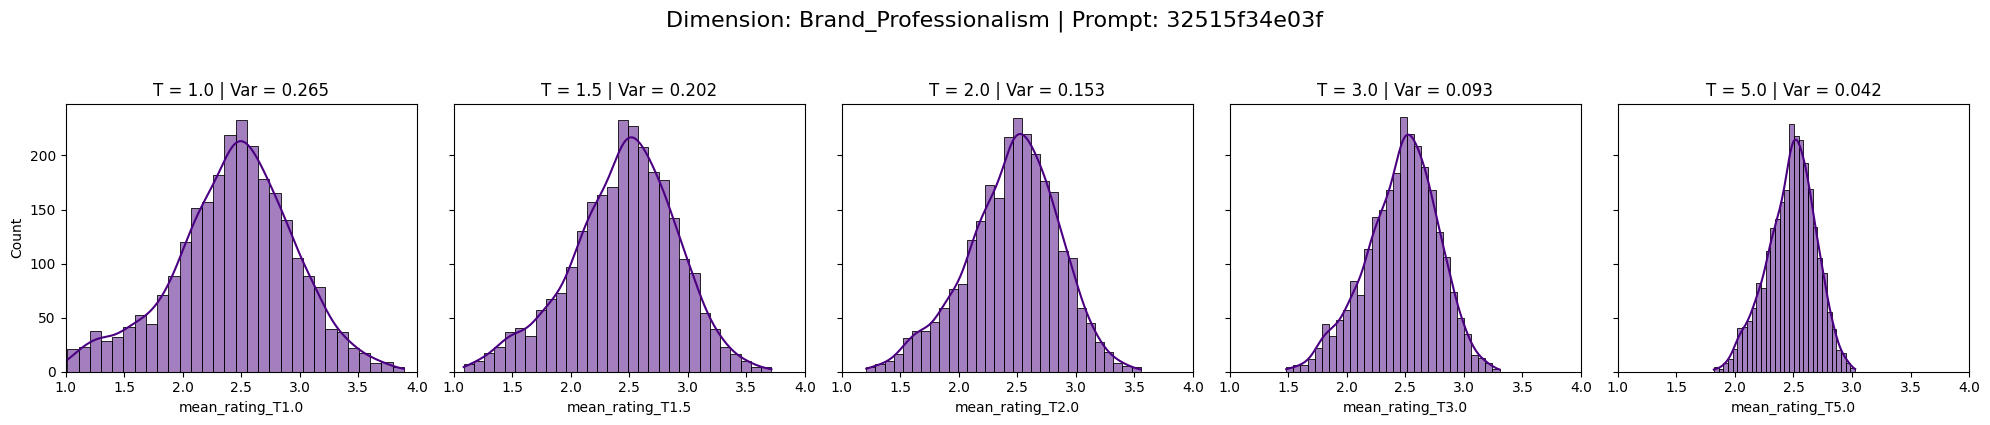

In [37]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup and Computation (Do this once for the whole DF)
weights = np.array([1.0, 2.0, 3.0, 4.0])
temperatures = [1.0, 1.5, 2.0, 3.0, 5.0]


def compute_temp_scaled_ev(logits_nested_list, T):
    logits = np.array(logits_nested_list[0], dtype=float)
    scaled_logits = logits / T
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits))
    probs = exp_logits / np.sum(exp_logits)
    weights_array = np.arange(len(probs)) + 1
    return np.sum(probs * weights_array)


print("Computing temperature-scaled columns...")
for T in temperatures:
    col_name = f'mean_rating_T{T}'
    final_df[col_name] = final_df['sorted_logits'].apply(
        lambda x: compute_temp_scaled_ev(x, T)
    )

# 2. Generate and Store the Plots in a Dictionary
print("Generating plots for the dashboard...")
plot_dict = {}

# Assuming 'dimension_name' is the "rating" category from your widget
groups = final_df.groupby(['dimension_name', 'prompt_id'])

for (dim, pid), group_df in groups:
    # Create the figure
    fig, axes = plt.subplots(1, len(temperatures),
                             figsize=(20, 4), sharey=True)
    fig.suptitle(f"Dimension: {dim} | Prompt: {pid}", fontsize=16, y=1.05)

    for i, T in enumerate(temperatures):
        col = f'mean_rating_T{T}'

        # Safely handle variance if the group is too small
        var_val = group_df[col].var() if len(group_df) > 1 else 0.0
        mean_val = group_df[col].mean()

        sns.histplot(group_df[col], bins=30, kde=True,
                     ax=axes[i], color='indigo')
        axes[i].set_title(f"T = {T} | Var = {var_val:.3f}")
        axes[i].set_xlim(1, 4)

    plt.tight_layout()
    # Crucial: prevents the plot from dumping to the cell immediately
    plt.close(fig)

    # Store the figure object in the dictionary using the tuple key your widget expects
    plot_dict[(dim, pid)] = fig

print("✓ Dashboard ready!")

# 3. The Interactive Widget (Adapted directly from your code)


def interactive_plot_selector(data_dict, description="Select option:"):
    # label -> value pairs; k[0] is dimension, k[1] is prompt_id
    options = [(f"prompt {k[1]} | {k[0]}", k) for k in data_dict.keys()]

    dropdown = widgets.Dropdown(
        options=options,
        description=description,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    def update_plot(change):
        clear_output(wait=True)
        display(dropdown)
        # Displaying a matplotlib Figure object renders it natively in Jupyter
        display(data_dict[change.new])

    dropdown.observe(update_plot, names='value')

    # Render the initial state
    display(dropdown)
    display(data_dict[dropdown.value])


# 4. Launch the dashboard!
interactive_plot_selector(plot_dict, description="Select Rating & Prompt:")

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure these map exactly to the order of your sorted_logits!
# We assume the logits correspond to tokens for ratings 1, 2, 3, 4.
weights = np.array([1.0, 2.0, 3.0, 4.0])

# The temperature scales we want to test
temperatures = [1.0, 1.5, 2.0, 3.0, 5.0]


def compute_temp_scaled_ev(logits_nested_list, T):
    """
    Safely calculates temperature-scaled expected values from a nested logit list.
    """
    # 1. Extract the inner list (logits for the first generated token)
    logits = np.array(logits_nested_list[0], dtype=float)

    # 2. Apply Temperature
    scaled_logits = logits / T

    # 3. Stable Softmax (subtract max to prevent overflow)
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits))
    probs = exp_logits / np.sum(exp_logits)

    # 4. Calculate Expected Value
    weights_array = np.arange(len(probs))+1
    return np.sum(probs * weights_array)


# Apply the function to create our new columns
for T in temperatures:
    col_name = f'mean_rating_T{T}'
    final_df[col_name] = final_df['sorted_logits'].apply(
        lambda x: compute_temp_scaled_ev(x, T)
    )

print("✓ Temperature-scaled columns created successfully.")

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_47532\2683194351.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[col_name] = final_df['sorted_logits'].apply(


✓ Temperature-scaled columns created successfully.


--- OLS Leverage Diagnostics (Variance Check) ---
T=1.0 | Variance: 0.5460 | Mean: 2.52
T=1.5 | Variance: 0.4551 | Mean: 2.52
T=2.0 | Variance: 0.3952 | Mean: 2.53
T=3.0 | Variance: 0.3146 | Mean: 2.53
T=5.0 | Variance: 0.2109 | Mean: 2.53


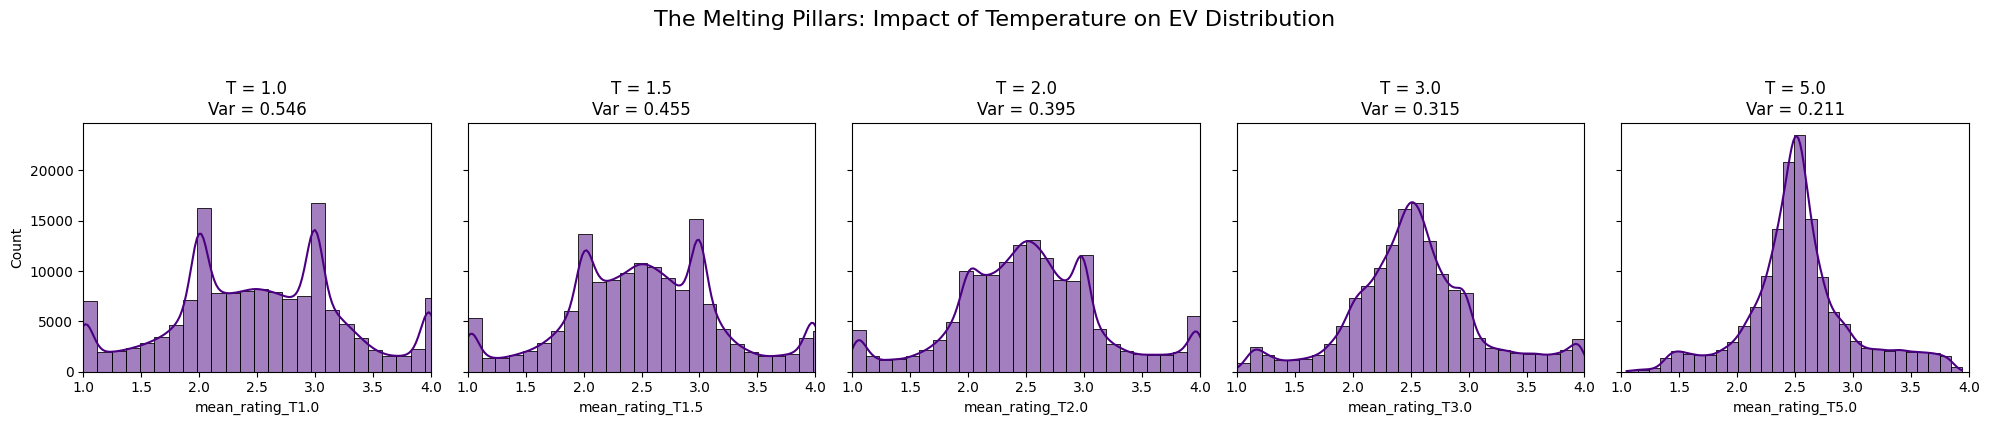

In [39]:
fig, axes = plt.subplots(1, len(temperatures), figsize=(20, 4), sharey=True)
fig.suptitle(
    f"The Melting Pillars: Impact of Temperature on EV Distribution", fontsize=16, y=1.05)

print("--- OLS Leverage Diagnostics (Variance Check) ---")

for i, T in enumerate(temperatures):
    col = f'mean_rating_T{T}'
    var_val = final_df[col].var()
    mean_val = final_df[col].mean()

    print(f"T={T} | Variance: {var_val:.4f} | Mean: {mean_val:.2f}")

    sns.histplot(final_df[col], bins=30, kde=True, ax=axes[i], color='indigo')
    axes[i].set_title(f"T = {T}\nVar = {var_val:.3f}")
    axes[i].set_xlim(1, 4)

plt.tight_layout()
plt.show()

In [40]:
final_df.columns

Index(['applicants_applications_count', 'content_types', 'deal_id',
       'main_image', 'min_social_media_followers', 'deal_tags', 'live_since',
       'first_application_at', 'last_application_at', 'company_locations',
       ...
       'mode_rating', 'scale_size', 'entropy', 'normalized_entropy',
       'first_content_type', 'mean_rating_T1.0', 'mean_rating_T1.5',
       'mean_rating_T2.0', 'mean_rating_T3.0', 'mean_rating_T5.0'],
      dtype='object', length=102)

--- OLS Leverage Diagnostics ---
Task_Clarity:
  Mean: 2.26 | Variance: 0.371 | Min-Max: 1.00 - 3.96

Brand_Professionalism:
  Mean: 2.44 | Variance: 0.265 | Min-Max: 1.01 - 3.89

Hook_Strength:
  Mean: 2.13 | Variance: 0.119 | Min-Max: 1.01 - 3.50



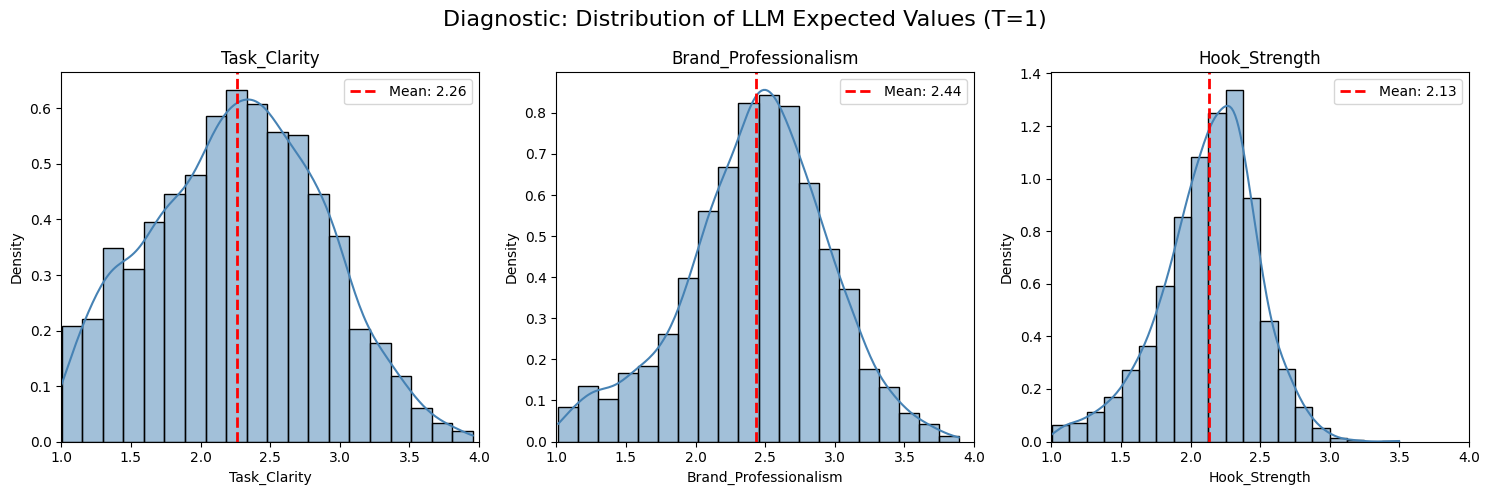

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

wide_df = final_df[final_df['prompt_id'] == '32515f34e03f'].pivot(
    index='input_id', columns='dimension_name', values='mean_rating')

# Assuming your wide_df contains the dimensions as columns.
# Replace these with your exact column names if they differ!
score_cols = ['Task_Clarity', 'Brand_Professionalism', 'Hook_Strength']

# Set up the plotting grid
fig, axes = plt.subplots(1, len(score_cols), figsize=(15, 5), sharey=False)
fig.suptitle(
    "Diagnostic: Distribution of LLM Expected Values (T=1)", fontsize=16)

print("--- OLS Leverage Diagnostics ---")

for i, col in enumerate(score_cols):
    # 1. Calculate and print the critical variance metrics
    col_var = wide_df[col].var()
    col_mean = wide_df[col].mean()
    print(f"{col}:")
    print(
        f"  Mean: {col_mean:.2f} | Variance: {col_var:.3f} | Min-Max: {wide_df[col].min():.2f} - {wide_df[col].max():.2f}\n")

    # 2. Plot the distribution
    sns.histplot(wide_df[col], bins=20, kde=True,
                 ax=axes[i], color='steelblue', stat='density')

    # 3. Add a vertical line for the mean to anchor the visual
    axes[i].axvline(col_mean, color='red', linestyle='dashed',
                    linewidth=2, label=f'Mean: {col_mean:.2f}')
    axes[i].set_title(col)
    axes[i].set_xlim(1, 4)  # Lock x-axis to our true 1-4 scale
    axes[i].legend()

plt.tight_layout()
plt.show()

-----------

# Rest

## Recoding physical liquidity vars
- I recoded the physical active vars to decrease the bucket granularity, but I opted to drop the physical deals altoghether instead

In [42]:
# active_creators_cols = ['log_online_active_0_7d',
#        'log_online_active_7_30d', 'log_phys_active_0_7d_0_10km',
#        'log_phys_active_0_7d_10_20km', 'log_phys_active_0_7d_20_50km',
#        'log_phys_active_7_30d_0_10km', 'log_phys_active_7_30d_10_20km',
#        'log_phys_active_7_30d_20_50km']

In [43]:
import numpy as np

# 1. Rebuild the Hyper-Local bin (0-10km, all 30 days)
df['phys_active_0_30d_0_10km'] = (
    df['phys_active_0_7d_0_10km'] +
    df['phys_active_7_30d_0_10km']
)
df['log_phys_active_0_30d_0_10km'] = np.log1p(df['phys_active_0_30d_0_10km'])

# 2. Rebuild the Local bin (10-20km, all 30 days)
df['phys_active_0_30d_10_20km'] = (
    df['phys_active_0_7d_10_20km'] +
    df['phys_active_7_30d_10_20km']
)
df['log_phys_active_0_30d_10_20km'] = np.log1p(df['phys_active_0_30d_10_20km'])

# 3. Rebuild the Regional bin (20-50km, all 30 days)
df['phys_active_0_30d_20_50km'] = (
    df['phys_active_0_7d_20_50km'] +
    df['phys_active_7_30d_20_50km']
)
df['log_phys_active_0_30d_20_50km'] = np.log1p(df['phys_active_0_30d_20_50km'])

In [44]:
# The newly consolidated list (5 features instead of 8)
active_creators_cols = [
    'log_online_active_0_7d',
    'log_online_active_7_30d',
    'log_phys_active_0_30d_0_10km',
    'log_phys_active_0_30d_10_20km',
    'log_phys_active_0_30d_20_50km'
]

# Ensure we don't accidentally append duplicates if you run the cell twice
CONTINUOUS = ['competitor_density']
# CONTINUOUS = [col for col in CONTINUOUS if col not in active_creators_cols]
CONTINUOUS += active_creators_cols


# 1. Isolate Physical Deals
df_phys = df[df['deal_type'] == 'physical'].copy()

# 2. Define strictly physical features (Drop online!)
phys_continuous = [
    'competitor_density',
    'log_phys_active_0_30d_0_10km',
    'log_phys_active_0_30d_10_20km',
    'log_phys_active_0_30d_20_50km'
]

# 3. Check if market_scope even has variance in physical deals
# (If all physical deals are in NLD, drop market_scope entirely!)
df_phys['market_scope'].value_counts()

# 4. Run the isolated model
ols_results = ols_runner.run_baseline_model(
    df=df_phys,
    cat_vars=[],  # Only include if value_counts shows distinct categories
    bin_vars=BINARIES,
    num_vars=phys_continuous,
    label="Isolated_Physical_OLS"
)

ValueError: zero-size array to reduction operation maximum which has no identity

## Other rest

In [ ]:
og_df.consolidated_categories.value_counts()

consolidated_categories
Other                        381
Lifestyle_Luxury             239
Beauty_UGC                   203
Fashion_Lifestyle            193
Activities_Sport             116
Cooking_Food                 110
Tech_UGC                     108
Mom_UGC                      107
Lifestyle_UGC                100
Food_Lifestyle                92
Animals_Lifestyle             88
Lifestyle_Nightlife           81
Food_Vegan                    76
Lifestyle_Travel              75
Drinks_Food                   70
Entertainment_Gaming          65
Lifestyle                     58
Lifestyle_Vegan               58
Cooking_Vegan                 56
Entertainment_Music           55
Drinks_Lifestyle              54
Finance_Lifestyle             53
Lifestyle_Photography         50
Cars_Lifestyle                49
Entertainment_Experiences     46
Beauty_Fashion                45
Experiences_Food              38
Entertainment_Lifestyle       36
Fashion_Mom                   31
Activities_Lifestyl

In [ ]:
subset_categories = ['Lifestyle_Luxury', 'Beauty_UGC', 'Fashion_Lifestyle']

In [ ]:
og_df['consolidated_categories'].isin(subset_categories).sum()

np.int64(635)

In [ ]:
subset_categories = ['Lifestyle', 'Lifestyle_Luxury',
                     'Beauty_UGC', 'Beauty_Fashion']

runner = create_regression_runner(
    target_col='log_apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='ols'
)

runner.run_baseline_model(
    df=og_df[og_df['consolidated_categories'].isin(subset_categories)],
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="baseline_model_OLS"
)

runner.run_regression(df=final_df[final_df['consolidated_categories'].isin(subset_categories)],
                      cat_vars=CATEGORICALS,
                      bin_vars=BINARIES,
                      num_vars=CONTINUOUS,
                      predictor_name='mean_rating')

interactive_regression_results_selector(runner.results)

✓ Baseline model fitted: 545.0 observations, AIC=1463.66


Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline_model_OLS', "('Qwen/Qw…

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     log_apps_after_7_days   R-squared:                       0.342
Model:                               OLS   Adj. R-squared:                  0.331
Method:                    Least Squares   F-statistic:                     21.67
Date:                   Fri, 13 Mar 2026   Prob (F-statistic):           1.46e-27
Time:                           10:53:23   Log-Likelihood:                -721.83
No. Observations:                    545   AIC:                             1464.
Df Residuals:                        535   BIC:                             1507.
Df Model:                              9                                         
Covariance Type:                 cluster                                         
============================================================================================================
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                        1.7235      0.530      3.254      0.001       0.681       2.766
competitor_density                           0.0174      0.028      0.613      0.540      -0.038       0.073
log_physical_active_creators_7d_50km         0.2727      0.100      2.717      0.007       0.075       0.470
log_online_eligible_last_week                0.2506      0.080      3.121      0.002       0.093       0.409
market_scope_Tier2_NLD_only                 -0.2669      0.123     -2.164      0.031      -0.510      -0.024
market_scope_Tier3_BEL_Only                 -0.4748      0.265     -1.794      0.074      -0.996       0.046
market_scope_Tier4_Germany                  -0.9351      0.246     -3.798      0.000      -1.420      -0.450
consolidated_categories_Beauty_UGC          -0.2572      0.189     -1.363      0.174      -0.629       0.114
consolidated_categories_Lifestyle            0.0656      0.222      0.296      0.767      -0.371       0.502
consolidated_categories_Lifestyle_Luxury    -0.0373      0.190     -0.196      0.845      -0.412       0.337
==============================================================================
Omnibus:                       34.447   Durbin-Watson:                   1.806
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               44.160
Skew:                          -0.542   Prob(JB):                     2.57e-10
Kurtosis:                       3.878   Cond. No.                         76.4
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [ ]:
qwen3_adjr2 = (0.404 - 0.352) / 0.352
qwen35_adjr2 = (0.420 - 0.361) / 0.361
llama_adjr2 = (0.371-0.348) / 0.348

print(f"qwen3 percent increase in adjr2: {qwen3_adjr2}")
print(f"qwen3.5 percent increase in adjr2: {qwen35_adjr2}")
print(f"llama percent increase in adjr2: {llama_adjr2}")




qwen3 percent increase in adjr2: 0.14772727272727287
qwen3.5 percent increase in adjr2: 0.1634349030470914
llama percent increase in adjr2: 0.06609195402298856
